<h1> This notebook is the code for experiment 9 on cooling towers, the code is currently unorganized, and there are some models used in this code that were omited from the final report due to lower performance </h1>

In [1]:
import pandas as pd


data = {

    'WFR_L_min': [
        1.0, 1.5, 2.0, 2.5,
        1.47, 1.47, 1.47, 1.47,
        2.50, 2.50, 2.50, 2.50
    ],
    'WIT_degC': [
        35.0, 35.0, 35.0, 35.0,
        35.0, 40.0, 43.5, 45.0,
        35.0, 35.0, 35.0, 35.0
    ],
    'AFR_L_s': [
        30.2, 30.2, 30.2, 30.2,
        30.0, 30.0, 30.0, 30.0,
        30.0, 45.0, 50.0, 60.0
    ],


    'Cooling_Load_kW': [
        0.31, 0.13, 1.01, 1.18,
        1.53, 1.03, 1.50, 1.39,
        1.05, 1.40, 1.44, 1.48
    ],
    'Effectiveness_pct': [
        54.6, 46.4, 48.8, 33.3,
        58.9, 52.3, 56.3, 58.2,
        52.3, 44.3, 36.9, 43.0
    ]
}

df_final = pd.DataFrame(data)
df_final.head()

,WFR_L_min,WIT_degC,AFR_L_s,Cooling_Load_kW,Effectiveness_pct
0,1.00,35.0,30.2,0.31,54.6
1,1.50,35.0,30.2,0.13,46.4
2,2.00,35.0,30.2,1.01,48.8
3,2.50,35.0,30.2,1.18,33.3
4,1.47,35.0,30.0,1.53,58.9


In [2]:
Input = df_final[['WFR_L_min', 'WIT_degC', 'AFR_L_s']]
Target_1 = df_final['Cooling_Load_kW']
Target_2 = df_final['Effectiveness_pct']

In the cell below do all ! uv pip download

In [3]:
!pip install pysr scikit-learn pygam matplotlib numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 12.9 MB/s eta 0:00:00


In [4]:
!uv pip install optuna

Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 257ms                                        
Prepared 2 packages in 111ms                                             
Installed 2 packages in 13ms                                
 + colorlog==6.10.1
 + optuna==4.7.0


## 1. Evolutionary Symbolic Regression (PySR)
Discover closed-form equations for **Cooling Load** and **Effectiveness** using genetic-programming-based symbolic regression.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pysr import PySRRegressor
import optuna
import seaborn as sns


sns.set_theme(style="whitegrid", font_scale=1.0)
SEABORN_PALETTE = sns.color_palette(sns.diverging_palette(230, 20, n=10))

In [6]:


X = Input.values
y1 = Target_1.values
y2 = Target_2.values
feature_names = ['WFR', 'WIT', 'AFR']


pysr_model_1 = PySRRegressor(
    niterations=200,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["square", "sqrt", "abs"],
    populations=20,
    population_size=40,
    maxsize=20,
    parsimony=0.01,
    random_state=42,
    deterministic=True,
    procs=0,
    multithreading=False,
    temp_equation_file=True,
)
pysr_model_1.fit(X, y1, variable_names=feature_names)


pysr_model_2 = PySRRegressor(
    niterations=200,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["square", "sqrt", "abs"],
    populations=20,
    population_size=40,
    maxsize=20,
    parsimony=0.01,
    random_state=42,
    deterministic=True,
    procs=0,
    multithreading=False,
    temp_equation_file=True,
)
pysr_model_2.fit(X, y2, variable_names=feature_names)


eq1_pysr = pysr_model_1.get_best()
eq2_pysr = pysr_model_2.get_best()
print("=== PySR Best Equations ===")
print(f"Cooling Load  : {eq1_pysr['equation']}")
print(f"Effectiveness : {eq2_pysr['equation']}")

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2858: UserWarning: The `multithreading: bool` parameter has been deprecated in favor of `parallelism: Literal['multithreading', 'serial', 'multiprocessing']`.
Previous usage of `multithreading=True` (default) is now `parallelism='multithreading'`; `multithreading=False, procs=0` is now `parallelism='serial'`; and `multithreading=True, procs={int}` is now `parallelism='multiprocessing', procs={int}`.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.410e+05
Progress: 566 / 4000 total iterations (14.150%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.967e-01  0.000e+00  y = 1.1208
3           1.705e-01  7.155e-02  y = sqrt(sqrt(WFR))
4           1.552e-01  9.390e-02  y = sqrt(WFR - 0.58634)
5           1.455e-01  6.454e-02  y = 1.8394 - (1.252 / WFR)
6           1.335e-01  8.586e-02  y = WIT * (0.016015 * abs(WFR))
7           1.021e-01  2.687e-01  y = ((WIT * 0.047796) + -1.1535) * WFR
9           1.011e-01  4.579e-03  y = (((WIT * 0.051339) + -1.2168) * WFR) + -0.13302
10          1.001e-01  1.031e-02  y = sqrt((((WIT / 7.4295) + WFR) + -5.0093) - 0.5552)
15          9.288e-02  1.500e-02  y = (WFR * (((WIT * 0.36653) + -7.8786) + (-373.42 / (AFR ...
                                    

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.967e-01  0.000e+00  y = 1.1208
3           1.705e-01  7.155e-02  y = sqrt(sqrt(WFR))
4           1.552e-01  9.390e-02  y = sqrt(WFR - 0.58634)
5           1.335e-01  1.504e-01  y = WIT * (0.016015 * WFR)
6           1.075e-01  2.172e-01  y = (WFR * square(WIT)) * 0.00044067
7           1.008e-01  6.427e-02  y = (WIT * 0.056064) + (-1.6528 / WFR)
8           9.984e-02  9.399e-03  y = sqrt((WFR + -5.9764) + (WIT / 6.8462))
9           4.418e-02  8.153e-01  y = WFR + ((-0.0033839 / (WFR + -1.4734)) + -1.1092)
10          2.992e-02  3.899e-01  y = (-0.0034738 / (WFR + -1.4734)) + abs(WFR + -1.1685)
11          2.951e-02  1.355e-02  y = (WFR * 0.52363) + (0.19806 / ((WFR + -1.4864) * -20.90...
                                      2))
12          2.595e-02  1.285e-01  y = sqrt(WFR - 0.88105) + (0.2459 / ((WFR + -1.4857) * -26...
       

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2858: UserWarning: The `multithreading: bool` parameter has been deprecated in favor of `parallelism: Literal['multithreading', 'serial', 'multiprocessing']`.
Previous usage of `multithreading=True` (default) is now `parallelism='multithreading'`; `multithreading=False, procs=0` is now `parallelism='serial'`; and `multithreading=True, procs={int}` is now `parallelism='multiprocessing', procs={int}`.
  warnings.warn(


  - /tmp/tmp9ta_q7la/20260303_165947_IZBWTX/hall_of_fame.csv

Expressions evaluated per second: 1.600e+05
Progress: 582 / 4000 total iterations (14.550%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.219e+01  0.000e+00  y = 48.775
3           4.546e+01  1.567e-01  y = WIT * 1.3183
4           3.166e+01  3.619e-01  y = square(WFR + -8.8599)
5           2.978e+01  6.099e-02  y = WIT + (22.568 / WFR)
6           2.800e+01  6.177e-02  y = 782.78 / (square(WFR) + 12.53)
7           2.685e+01  4.180e-02  y = square(abs(WFR + -1.2625) - 7.6513)
8           2.542e+01  5.487e-02  y = sqrt(((WFR * -23.706) + 110.02) * WIT)
9           2.525e+01  6.545e-03  y = (((WFR * -0.26277) + 0.92496) * WIT) + 32.882
10          2.510e+01  5.971e-03  y = sqrt(((WFR * -18.689) + 84.111) * (WIT + 12.5

[ Info: Started!



Expressions evaluated per second: 1.530e+05
Progress: 2272 / 4000 total iterations (56.800%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.219e+01  0.000e+00  y = 48.775
3           4.546e+01  1.567e-01  y = WIT * 1.3183
4           3.166e+01  3.619e-01  y = square(WFR + -8.8599)
5           2.819e+01  1.161e-01  y = (WFR * -10.767) + 69.304
6           2.774e+01  1.598e-02  y = 813.93 / (square(WFR) + 13.011)
7           2.685e+01  3.247e-02  y = square(abs(WFR + -1.2625) - 7.6513)
8           2.542e+01  5.487e-02  y = sqrt(((WFR * -23.706) + 110.02) * WIT)
9           2.525e+01  6.545e-03  y = (((WFR * -0.26278) + 0.92493) * WIT) + 32.884
10          2.505e+01  8.227e-03  y = sqrt(((-17.02 * WFR) + 61.701) * WIT) + 16.242
12          2.500e+01  9.360e-04  y = (WFR + sqrt(((W

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.219e+01  0.000e+00  y = 48.775
3           4.546e+01  1.567e-01  y = WIT * 1.3183
4           3.166e+01  3.619e-01  y = square(WFR + -8.8599)
5           2.819e+01  1.161e-01  y = (WFR * -10.767) + 69.304
6           2.712e+01  3.839e-02  y = (square(WFR) * -2.8768) + 60.077
7           2.577e+01  5.134e-02  y = ((WFR * -349.38) / WIT) + 67.145
8           2.542e+01  1.360e-02  y = sqrt(((WFR * -23.706) + 110.02) * WIT)
9           2.525e+01  6.545e-03  y = (((WFR * -0.26278) + 0.92493) * WIT) + 32.884
10          2.505e+01  8.227e-03  y = sqrt(((-17.02 * WFR) + 61.701) * WIT) + 16.242
12          2.484e+01  4.087e-03  y = sqrt((WIT + 18.675) * (((WFR * WFR) * -4.423) + 60.541...
                                      ))
13          2.455e+01  1.184e-02  y = sqrt(square(AFR + -46.833) + (WIT * ((WFR * -20.963) +...
                 

<lambdifygenerated-11>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(WFR - WFR/(-AFR + WIT) - 0.6671222) + 0.18512224/(31.053981021888 - 20.90176*WFR)


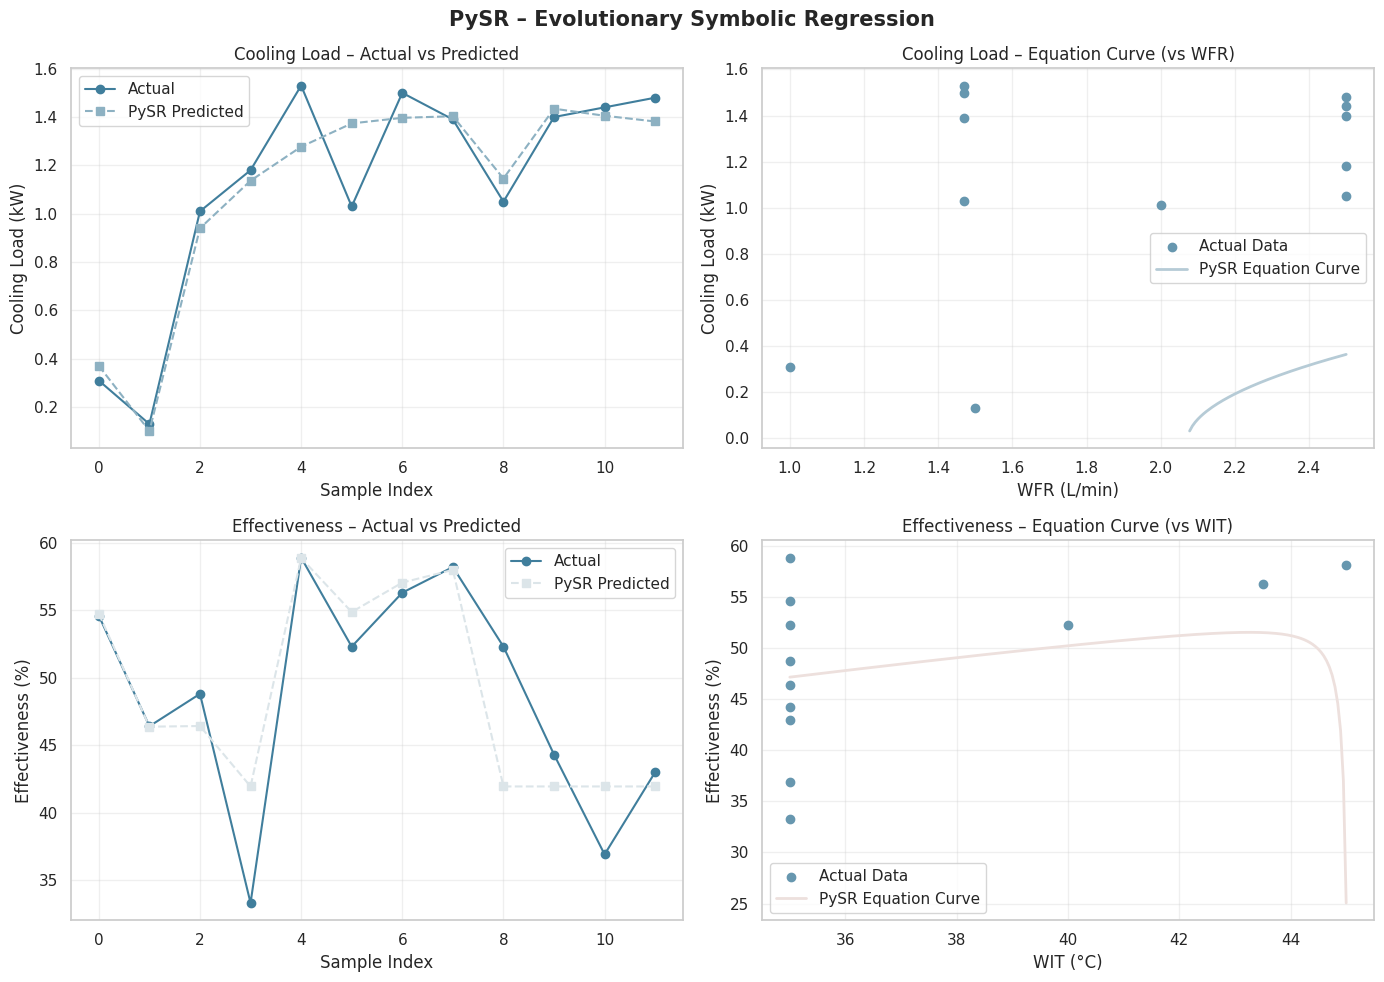


PySR Cooling Load  R² = 0.9045
PySR Effectiveness R² = 0.6959


In [27]:

y1_pred_pysr = pysr_model_1.predict(X)
y2_pred_pysr = pysr_model_2.predict(X)

pal = SEABORN_PALETTE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("PySR – Evolutionary Symbolic Regression", fontsize=15, fontweight='bold')

sample_idx = np.arange(len(y1))


axes[0, 0].plot(sample_idx, y1, marker='o', linestyle='-', color=pal[0], label='Actual')
axes[0, 0].plot(sample_idx, y1_pred_pysr, marker='s', linestyle='--', color=pal[2], label='PySR Predicted')
axes[0, 0].set_title('Cooling Load – Actual vs Predicted')
axes[0, 0].set_xlabel('Sample Index'); axes[0, 0].set_ylabel('Cooling Load (kW)')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)



X_dense = np.tile(X.mean(axis=0), (200, 1))
wfr_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
X_dense[:, 0] = wfr_range
y1_smooth = pysr_model_1.predict(X_dense)
axes[0, 1].scatter(X[:, 0], y1, color=pal[1], zorder=5, label='Actual Data')
axes[0, 1].plot(wfr_range, y1_smooth, linewidth=2, color=pal[3], label='PySR Equation Curve')
axes[0, 1].set_title('Cooling Load – Equation Curve (vs WFR)')
axes[0, 1].set_xlabel('WFR (L/min)'); axes[0, 1].set_ylabel('Cooling Load (kW)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)


axes[1, 0].plot(sample_idx, y2, marker='o', linestyle='-', color=pal[0], label='Actual')
axes[1, 0].plot(sample_idx, y2_pred_pysr, marker='s', linestyle='--', color=pal[4], label='PySR Predicted')
axes[1, 0].set_title('Effectiveness – Actual vs Predicted')
axes[1, 0].set_xlabel('Sample Index'); axes[1, 0].set_ylabel('Effectiveness (%)')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)


X_dense2 = np.tile(X.mean(axis=0), (200, 1))
wit_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 200)
X_dense2[:, 1] = wit_range
y2_smooth = pysr_model_2.predict(X_dense2)
axes[1, 1].scatter(X[:, 1], y2, color=pal[1], zorder=5, label='Actual Data')
axes[1, 1].plot(wit_range, y2_smooth, linewidth=2, color=pal[5], label='PySR Equation Curve')
axes[1, 1].set_title('Effectiveness – Equation Curve (vs WIT)')
axes[1, 1].set_xlabel('WIT (°C)'); axes[1, 1].set_ylabel('Effectiveness (%)')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPySR Cooling Load  R² = {1 - np.sum((y1 - y1_pred_pysr)**2)/np.sum((y1 - y1.mean())**2):.4f}")
print(f"PySR Effectiveness R² = {1 - np.sum((y2 - y2_pred_pysr)**2)/np.sum((y2 - y2.mean())**2):.4f}")

## 2. Sparse Dictionary Learning (LASSO / Elastic Net with Feature Expansion)
Build a polynomial + interaction feature library, then use **LASSO** and **Elastic Net** to select sparse coefficients → interpretable equation.

In [6]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X)
poly_names = poly.get_feature_names_out(feature_names)
print(f"Expanded features ({len(poly_names)}): {list(poly_names)}")

scaler = StandardScaler()
X_poly_sc = scaler.fit_transform(X_poly)



lasso_cv_1 = LassoCV(alphas=np.logspace(-4, 1, 100), cv=min(5, len(y1)), max_iter=50000, random_state=42)
lasso_cv_1.fit(X_poly_sc, y1)

enet_cv_1 = ElasticNetCV(alphas=np.logspace(-4, 1, 100), l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.99],
                          cv=min(5, len(y1)), max_iter=50000, random_state=42)
enet_cv_1.fit(X_poly_sc, y1)


lasso_cv_2 = LassoCV(alphas=np.logspace(-4, 1, 100), cv=min(5, len(y2)), max_iter=50000, random_state=42)
lasso_cv_2.fit(X_poly_sc, y2)

enet_cv_2 = ElasticNetCV(alphas=np.logspace(-4, 1, 100), l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.99],
                          cv=min(5, len(y2)), max_iter=50000, random_state=42)
enet_cv_2.fit(X_poly_sc, y2)


def sparse_equation(model, names, scaler, target_name, model_name):

    coef_orig = model.coef_ / scaler.scale_
    intercept_orig = model.intercept_ - np.sum(model.coef_ * scaler.mean_ / scaler.scale_)
    terms = []
    for c, name in zip(coef_orig, names):
        if abs(c) > 1e-8:
            terms.append(f"{c:+.4f}*{name}")
    eq = f"{intercept_orig:.4f} " + " ".join(terms)
    print(f"\n[{model_name}] {target_name}:")
    print(f"  y = {eq}")
    print(f"  Non-zero terms: {np.sum(np.abs(coef_orig) > 1e-8)} / {len(coef_orig)}")
    return coef_orig, intercept_orig

print("=" * 60)
print("LASSO / Elastic Net — Discovered Equations")
print("=" * 60)
c1_l, i1_l = sparse_equation(lasso_cv_1, poly_names, scaler, "Cooling Load", "LASSO")
c1_e, i1_e = sparse_equation(enet_cv_1, poly_names, scaler, "Cooling Load", "ElasticNet")
c2_l, i2_l = sparse_equation(lasso_cv_2, poly_names, scaler, "Effectiveness", "LASSO")
c2_e, i2_e = sparse_equation(enet_cv_2, poly_names, scaler, "Effectiveness", "ElasticNet")

Expanded features (9): ['WFR', 'WIT', 'AFR', 'WFR^2', 'WFR WIT', 'WFR AFR', 'WIT^2', 'WIT AFR', 'AFR^2']
LASSO / Elastic Net — Discovered Equations

[LASSO] Cooling Load:
  y = 1.1208 
  Non-zero terms: 0 / 9

[ElasticNet] Cooling Load:
  y = 1.1208 
  Non-zero terms: 0 / 9

[LASSO] Effectiveness:
  y = 51.9485 -2.0210*WFR^2 -0.0114*WFR AFR +0.0040*WIT^2
  Non-zero terms: 3 / 9

[ElasticNet] Effectiveness:
  y = 49.7368 -1.6348*WFR +0.1881*WIT -0.0348*AFR -0.4420*WFR^2 -0.0432*WFR WIT -0.0172*WFR AFR +0.0024*WIT^2 -0.0003*WIT AFR -0.0003*AFR^2
  Non-zero terms: 9 / 9


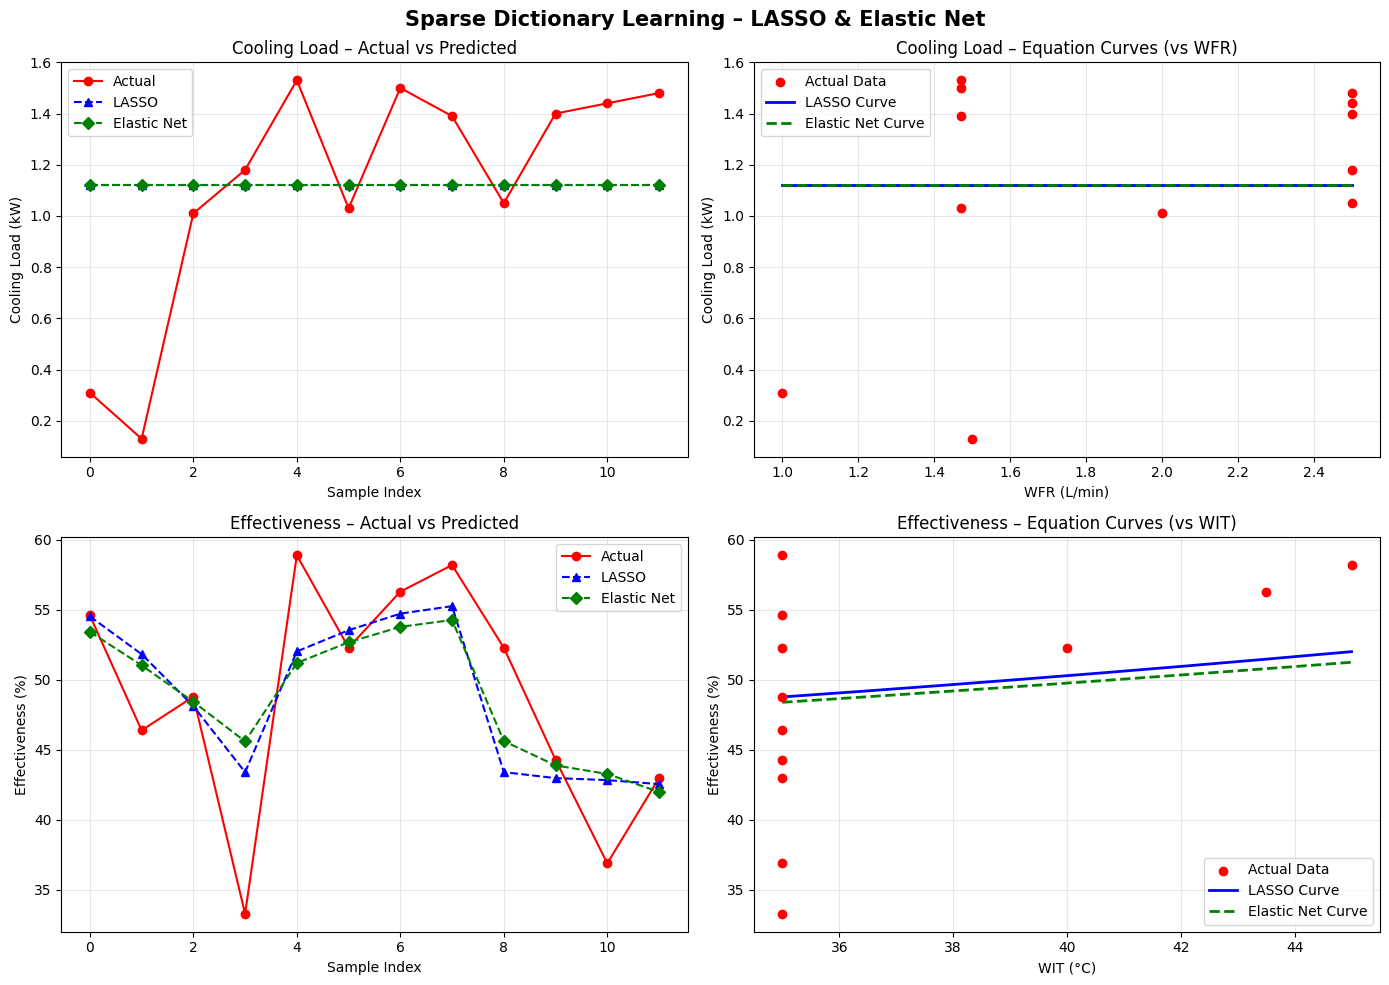


LASSO  Cooling Load  R² = 0.0000
ENet   Cooling Load  R² = 0.0000
LASSO  Effectiveness R² = 0.5870
ENet   Effectiveness R² = 0.5419


In [ ]:

y1_pred_lasso = lasso_cv_1.predict(X_poly_sc)
y1_pred_enet  = enet_cv_1.predict(X_poly_sc)
y2_pred_lasso = lasso_cv_2.predict(X_poly_sc)
y2_pred_enet  = enet_cv_2.predict(X_poly_sc)

pal = SEABORN_PALETTE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Sparse Dictionary Learning – LASSO & Elastic Net", fontsize=15, fontweight='bold')


axes[0, 0].plot(sample_idx, y1, marker='o', linestyle='-', color=pal[0], label='Actual')
axes[0, 0].plot(sample_idx, y1_pred_lasso, marker='^', linestyle='--', color=pal[2], label='LASSO')
axes[0, 0].plot(sample_idx, y1_pred_enet, marker='D', linestyle='--', color=pal[4], label='Elastic Net')
axes[0, 0].set_title('Cooling Load – Actual vs Predicted')
axes[0, 0].set_xlabel('Sample Index'); axes[0, 0].set_ylabel('Cooling Load (kW)')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)


wfr_dense = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
X_sweep = np.tile(X.mean(axis=0), (200, 1))
X_sweep[:, 0] = wfr_dense
X_sweep_poly = poly.transform(X_sweep)
X_sweep_sc = scaler.transform(X_sweep_poly)
y1_smooth_lasso = lasso_cv_1.predict(X_sweep_sc)
y1_smooth_enet  = enet_cv_1.predict(X_sweep_sc)
axes[0, 1].scatter(X[:, 0], y1, color=pal[1], zorder=5, label='Actual Data')
axes[0, 1].plot(wfr_dense, y1_smooth_lasso, lw=2, color=pal[2], label='LASSO Curve')
axes[0, 1].plot(wfr_dense, y1_smooth_enet, lw=2, linestyle='--', color=pal[4], label='Elastic Net Curve')
axes[0, 1].set_title('Cooling Load – Equation Curves (vs WFR)')
axes[0, 1].set_xlabel('WFR (L/min)'); axes[0, 1].set_ylabel('Cooling Load (kW)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)


axes[1, 0].plot(sample_idx, y2, marker='o', linestyle='-', color=pal[0], label='Actual')
axes[1, 0].plot(sample_idx, y2_pred_lasso, marker='^', linestyle='--', color=pal[2], label='LASSO')
axes[1, 0].plot(sample_idx, y2_pred_enet, marker='D', linestyle='--', color=pal[4], label='Elastic Net')
axes[1, 0].set_title('Effectiveness – Actual vs Predicted')
axes[1, 0].set_xlabel('Sample Index'); axes[1, 0].set_ylabel('Effectiveness (%)')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)


wit_dense = np.linspace(X[:, 1].min(), X[:, 1].max(), 200)
X_sweep2 = np.tile(X.mean(axis=0), (200, 1))
X_sweep2[:, 1] = wit_dense
X_sweep2_poly = poly.transform(X_sweep2)
X_sweep2_sc = scaler.transform(X_sweep2_poly)
y2_smooth_lasso = lasso_cv_2.predict(X_sweep2_sc)
y2_smooth_enet  = enet_cv_2.predict(X_sweep2_sc)
axes[1, 1].scatter(X[:, 1], y2, color=pal[1], zorder=5, label='Actual Data')
axes[1, 1].plot(wit_dense, y2_smooth_lasso, lw=2, color=pal[2], label='LASSO Curve')
axes[1, 1].plot(wit_dense, y2_smooth_enet, lw=2, linestyle='--', color=pal[4], label='Elastic Net Curve')
axes[1, 1].set_title('Effectiveness – Equation Curves (vs WIT)')
axes[1, 1].set_xlabel('WIT (°C)'); axes[1, 1].set_ylabel('Effectiveness (%)')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLASSO  Cooling Load  R² = {1 - np.sum((y1-y1_pred_lasso)**2)/np.sum((y1-y1.mean())**2):.4f}")
print(f"ENet   Cooling Load  R² = {1 - np.sum((y1-y1_pred_enet)**2)/np.sum((y1-y1.mean())**2):.4f}")
print(f"LASSO  Effectiveness R² = {1 - np.sum((y2-y2_pred_lasso)**2)/np.sum((y2-y2.mean())**2):.4f}")
print(f"ENet   Effectiveness R² = {1 - np.sum((y2-y2_pred_enet)**2)/np.sum((y2-y2.mean())**2):.4f}")

## 3. Generalized Additive Models (GAMs) via Penalized Splines
Fit a **GAM** with penalized B-splines for each input feature. The model is additive: $y = f_1(\text{WFR}) + f_2(\text{WIT}) + f_3(\text{AFR})$, making each partial effect interpretable.

In [8]:
from pygam import LinearGAM, s





gam_1 = LinearGAM(s(0, n_splines=5) + s(1, n_splines=5) + s(2, n_splines=5))
gam_1.gridsearch(X, y1, progress=False)
print("=== GAM — Cooling Load ===")
print(gam_1.summary())


gam_2 = LinearGAM(s(0, n_splines=5) + s(1, n_splines=5) + s(2, n_splines=5))
gam_2.gridsearch(X, y2, progress=False)
print("\n=== GAM — Effectiveness ===")
print(gam_2.summary())

=== GAM — Cooling Load ===
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      3.0004
Link Function:                     IdentityLink Log Likelihood:                                    -3.2451
Number of Samples:                           12 AIC:                                               14.4911
                                                AICc:                                              20.2068
                                                GCV:                                                0.2292
                                                Scale:                                              0.3593
                                                Pseudo R-Squared:                                   0.5077
Feature Fu

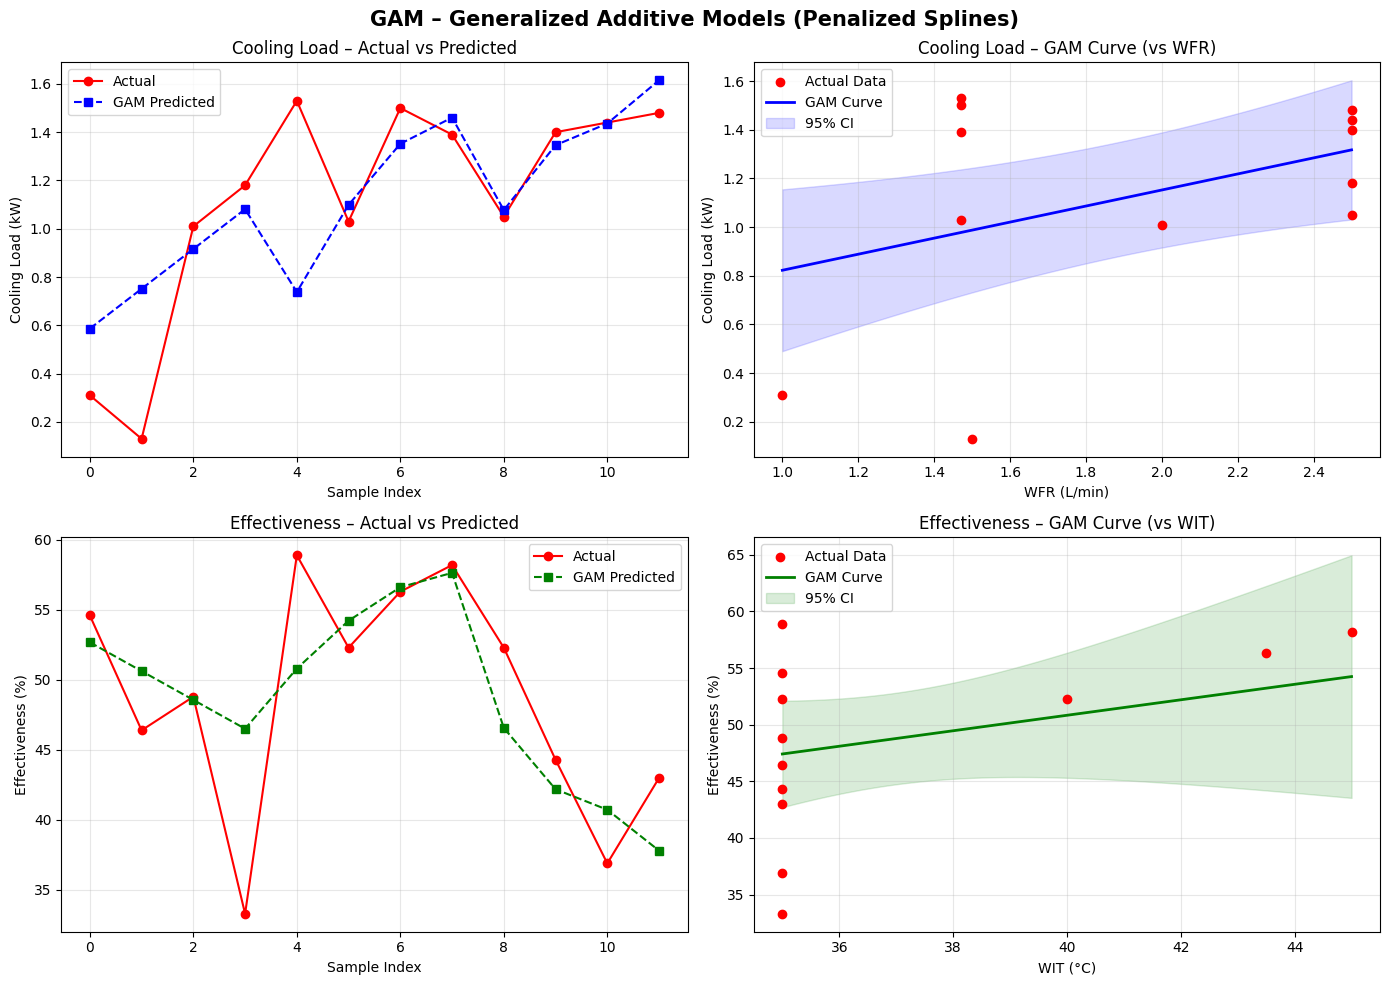


GAM Cooling Load  R² = 0.5077
GAM Effectiveness R² = 0.5382


In [ ]:

y1_pred_gam = gam_1.predict(X)
y2_pred_gam = gam_2.predict(X)

pal = SEABORN_PALETTE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("GAM – Generalized Additive Models (Penalized Splines)", fontsize=15, fontweight='bold')


axes[0, 0].plot(sample_idx, y1, marker='o', linestyle='-', color=pal[0], label='Actual')
axes[0, 0].plot(sample_idx, y1_pred_gam, marker='s', linestyle='--', color=pal[2], label='GAM Predicted')
axes[0, 0].set_title('Cooling Load – Actual vs Predicted')
axes[0, 0].set_xlabel('Sample Index'); axes[0, 0].set_ylabel('Cooling Load (kW)')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)


wfr_dense_gam = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
X_gam_sweep = np.tile(X.mean(axis=0), (200, 1))
X_gam_sweep[:, 0] = wfr_dense_gam
y1_smooth_gam = gam_1.predict(X_gam_sweep)
y1_ci = gam_1.confidence_intervals(X_gam_sweep, width=0.95)
axes[0, 1].scatter(X[:, 0], y1, color=pal[1], zorder=5, label='Actual Data')
axes[0, 1].plot(wfr_dense_gam, y1_smooth_gam, lw=2, color=pal[3], label='GAM Curve')
axes[0, 1].fill_between(wfr_dense_gam, y1_ci[:, 0], y1_ci[:, 1], alpha=0.15, color=pal[3], label='95% CI')
axes[0, 1].set_title('Cooling Load – GAM Curve (vs WFR)')
axes[0, 1].set_xlabel('WFR (L/min)'); axes[0, 1].set_ylabel('Cooling Load (kW)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)


axes[1, 0].plot(sample_idx, y2, marker='o', linestyle='-', color=pal[0], label='Actual')
axes[1, 0].plot(sample_idx, y2_pred_gam, marker='s', linestyle='--', color=pal[4], label='GAM Predicted')
axes[1, 0].set_title('Effectiveness – Actual vs Predicted')
axes[1, 0].set_xlabel('Sample Index'); axes[1, 0].set_ylabel('Effectiveness (%)')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)


wit_dense_gam = np.linspace(X[:, 1].min(), X[:, 1].max(), 200)
X_gam_sweep2 = np.tile(X.mean(axis=0), (200, 1))
X_gam_sweep2[:, 1] = wit_dense_gam
y2_smooth_gam = gam_2.predict(X_gam_sweep2)
y2_ci = gam_2.confidence_intervals(X_gam_sweep2, width=0.95)
axes[1, 1].scatter(X[:, 1], y2, color=pal[1], zorder=5, label='Actual Data')
axes[1, 1].plot(wit_dense_gam, y2_smooth_gam, lw=2, color=pal[5], label='GAM Curve')
axes[1, 1].fill_between(wit_dense_gam, y2_ci[:, 0], y2_ci[:, 1], alpha=0.15, color=pal[5], label='95% CI')
axes[1, 1].set_title('Effectiveness – GAM Curve (vs WIT)')
axes[1, 1].set_xlabel('WIT (°C)'); axes[1, 1].set_ylabel('Effectiveness (%)')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nGAM Cooling Load  R² = {1 - np.sum((y1-y1_pred_gam)**2)/np.sum((y1-y1.mean())**2):.4f}")
print(f"GAM Effectiveness R² = {1 - np.sum((y2-y2_pred_gam)**2)/np.sum((y2-y2.mean())**2):.4f}")

### GAM – Partial Dependence (Individual Spline Terms)
Each subplot shows the isolated effect of one input feature on the target.

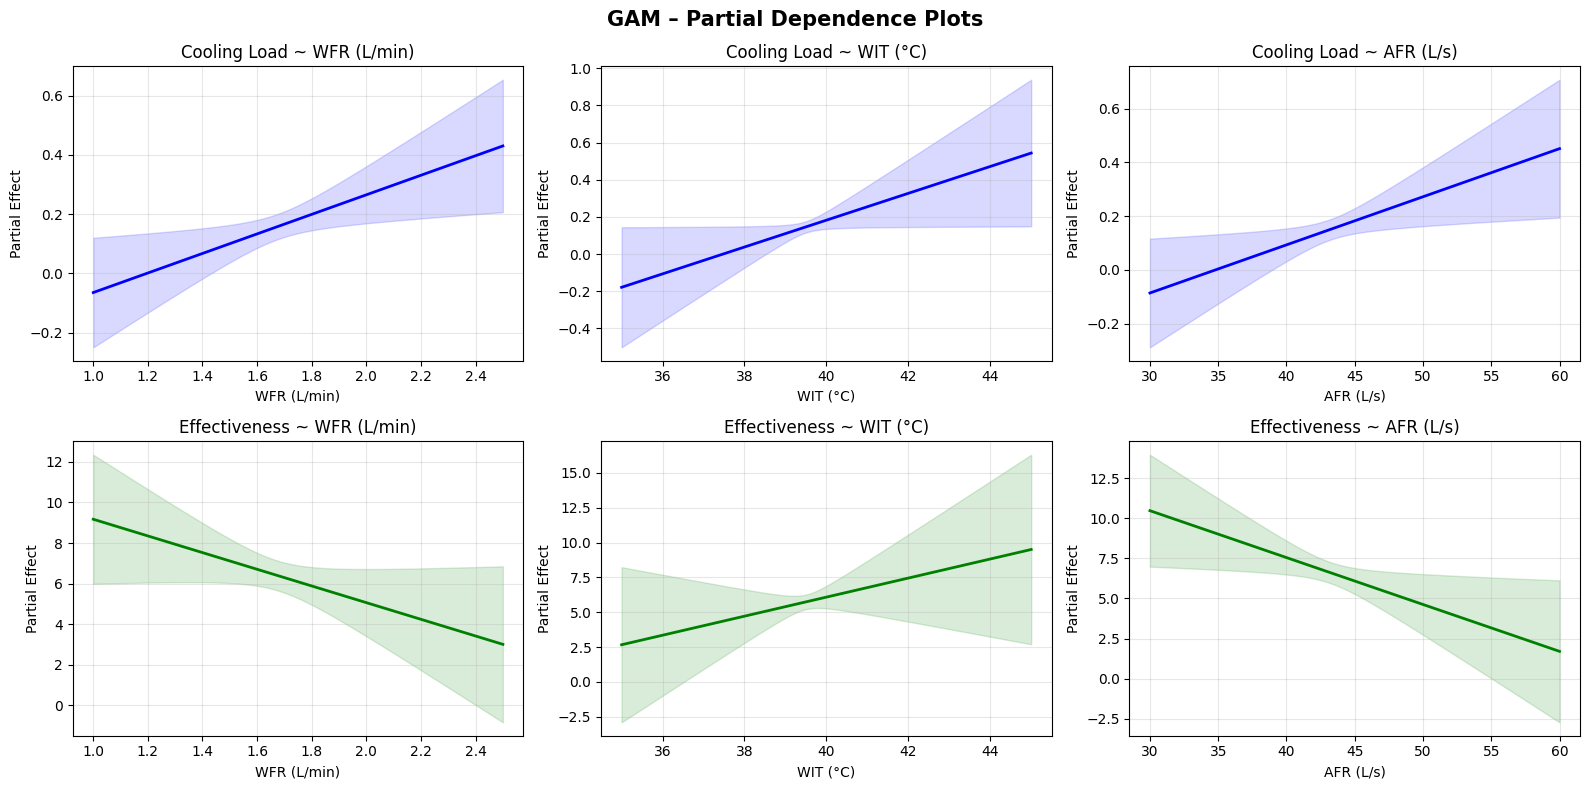

In [ ]:

titles = ['WFR (L/min)', 'WIT (°C)', 'AFR (L/s)']
pal = SEABORN_PALETTE

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("GAM – Partial Dependence Plots", fontsize=15, fontweight='bold')

for i, ax in enumerate(axes[0]):
    XX = gam_1.generate_X_grid(term=i, n=200)
    pdep, confi = gam_1.partial_dependence(term=i, X=XX, width=0.95)
    ax.plot(XX[:, i], pdep, lw=2, color=pal[2])
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.15, color=pal[2])
    ax.set_title(f'Cooling Load ~ {titles[i]}')
    ax.set_xlabel(titles[i]); ax.set_ylabel('Partial Effect')
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes[1]):
    XX = gam_2.generate_X_grid(term=i, n=200)
    pdep, confi = gam_2.partial_dependence(term=i, X=XX, width=0.95)
    ax.plot(XX[:, i], pdep, lw=2, color=pal[5])
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.15, color=pal[5])
    ax.set_title(f'Effectiveness ~ {titles[i]}')
    ax.set_xlabel(titles[i]); ax.set_ylabel('Partial Effect')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 3-Fold Cross-Validation Comparison
Compare all models (**PySR**, **LASSO**, **Elastic Net**, **GAM**) on both targets using 3-fold CV.  
Metrics: **R²** and **RMSE** per fold and averaged.

In [11]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LassoCV, ElasticNetCV
from pygam import LinearGAM, s
from pysr import PySRRegressor
import numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')


X = Input.values
y1 = Target_1.values
y2 = Target_2.values
feature_names = ['WFR', 'WIT', 'AFR']

kf = KFold(n_splits=3, shuffle=True, random_state=42)

model_names = ['PySR', 'LASSO', 'Elastic Net', 'GAM']

cv_results = {
    'Cooling Load':  {m: {'r2': [], 'rmse': []} for m in model_names},
    'Effectiveness': {m: {'r2': [], 'rmse': []} for m in model_names},
}

for fold_i, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\n{'='*50}")
    print(f" FOLD {fold_i+1}  |  Train: {list(train_idx)}  Test: {list(test_idx)}")
    print(f"{'='*50}")

    X_tr, X_te = X[train_idx], X[test_idx]
    y1_tr, y1_te = y1[train_idx], y1[test_idx]
    y2_tr, y2_te = y2[train_idx], y2[test_idx]


    for target_label, y_tr, y_te in [('Cooling Load', y1_tr, y1_te),
                                      ('Effectiveness', y2_tr, y2_te)]:
        psr = PySRRegressor(
            niterations=150, binary_operators=["+","-","*","/"],
            unary_operators=["square","sqrt","abs"],
            populations=15, population_size=30, maxsize=18,
            parsimony=0.02, random_state=42, deterministic=True,
            procs=0, multithreading=False, temp_equation_file=True,
            verbosity=0,
        )
        psr.fit(X_tr, y_tr, variable_names=feature_names)
        y_pred = psr.predict(X_te)
        cv_results[target_label]['PySR']['r2'].append(r2_score(y_te, y_pred))
        cv_results[target_label]['PySR']['rmse'].append(np.sqrt(mean_squared_error(y_te, y_pred)))


    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_tr_poly = poly.fit_transform(X_tr)
    X_te_poly = poly.transform(X_te)
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr_poly)
    X_te_sc = sc.transform(X_te_poly)

    for target_label, y_tr_t, y_te_t in [('Cooling Load', y1_tr, y1_te),
                                           ('Effectiveness', y2_tr, y2_te)]:

        lasso = LassoCV(alphas=np.logspace(-4, 1, 80), cv=min(3, len(y_tr_t)),
                         max_iter=50000, random_state=42)
        lasso.fit(X_tr_sc, y_tr_t)
        yp = lasso.predict(X_te_sc)
        cv_results[target_label]['LASSO']['r2'].append(r2_score(y_te_t, yp))
        cv_results[target_label]['LASSO']['rmse'].append(np.sqrt(mean_squared_error(y_te_t, yp)))


        enet = ElasticNetCV(alphas=np.logspace(-4, 1, 80),
                            l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.99],
                            cv=min(3, len(y_tr_t)), max_iter=50000, random_state=42)
        enet.fit(X_tr_sc, y_tr_t)
        yp = enet.predict(X_te_sc)
        cv_results[target_label]['Elastic Net']['r2'].append(r2_score(y_te_t, yp))
        cv_results[target_label]['Elastic Net']['rmse'].append(np.sqrt(mean_squared_error(y_te_t, yp)))


    for target_label, y_tr_t, y_te_t in [('Cooling Load', y1_tr, y1_te),
                                           ('Effectiveness', y2_tr, y2_te)]:
        gam = LinearGAM(s(0, n_splines=4) + s(1, n_splines=4) + s(2, n_splines=4))
        gam.gridsearch(X_tr, y_tr_t, progress=False)
        yp = gam.predict(X_te)
        cv_results[target_label]['GAM']['r2'].append(r2_score(y_te_t, yp))
        cv_results[target_label]['GAM']['rmse'].append(np.sqrt(mean_squared_error(y_te_t, yp)))

print("\n\n✅ 3-Fold CV complete for all models.")


 FOLD 1  |  Train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(11)]  Test: [np.int64(0), np.int64(8), np.int64(9), np.int64(10)]

 FOLD 2  |  Train: [np.int64(0), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]  Test: [np.int64(1), np.int64(2), np.int64(5), np.int64(11)]

 FOLD 3  |  Train: [np.int64(0), np.int64(1), np.int64(2), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]  Test: [np.int64(3), np.int64(4), np.int64(6), np.int64(7)]


✅ 3-Fold CV complete for all models.


In [12]:

import pandas as pd

rows = []
for target in ['Cooling Load', 'Effectiveness']:
    for model in model_names:
        r2_vals  = cv_results[target][model]['r2']
        rmse_vals = cv_results[target][model]['rmse']
        rows.append({
            'Target': target,
            'Model': model,
            'Fold 1 R²': r2_vals[0], 'Fold 2 R²': r2_vals[1], 'Fold 3 R²': r2_vals[2],
            'Mean R²': np.mean(r2_vals), 'Std R²': np.std(r2_vals),
            'Fold 1 RMSE': rmse_vals[0], 'Fold 2 RMSE': rmse_vals[1], 'Fold 3 RMSE': rmse_vals[2],
            'Mean RMSE': np.mean(rmse_vals), 'Std RMSE': np.std(rmse_vals),
        })

cv_df = pd.DataFrame(rows)
print("=" * 80)
print("3-Fold Cross-Validation Summary")
print("=" * 80)
display(cv_df.style.format(precision=4).set_caption("3-Fold CV Results"))

3-Fold Cross-Validation Summary


,Target,Model,Fold 1 R²,Fold 2 R²,Fold 3 R²,Mean R²,Std R²,Fold 1 RMSE,Fold 2 RMSE,Fold 3 RMSE,Mean RMSE,Std RMSE
0,Cooling Load,PySR,0.5438,-4.5821,-24.4336,-9.4906,10.7715,0.3062,1.1560,0.6924,0.7182,0.3474
1,Cooling Load,LASSO,-0.0549,0.2446,-14.0052,-4.6052,6.6479,0.4657,0.4253,0.5318,0.4743,0.0439
2,Cooling Load,Elastic Net,-0.0549,0.2454,-14.3275,-4.7123,6.8000,0.4657,0.4250,0.5375,0.4761,0.0465
3,Cooling Load,GAM,-0.0898,-0.0207,-32.9308,-11.0138,15.4977,0.4733,0.4943,0.7997,0.5891,0.1492
4,Effectiveness,PySR,-1.1759,-2.7640,0.2720,-1.2226,1.2399,10.3031,6.5884,9.0879,8.6598,1.5465
5,Effectiveness,LASSO,-0.8071,-0.8179,-0.0289,-0.5513,0.3694,9.3895,4.5787,10.8040,8.2574,2.6646
6,Effectiveness,Elastic Net,-0.8106,-0.6575,0.2804,-0.3959,0.4823,9.3987,4.3720,9.0357,7.6021,2.2889
7,Effectiveness,GAM,0.4455,-2.0562,0.3558,-0.4183,1.1588,5.2013,5.9367,8.5490,6.5623,1.4365


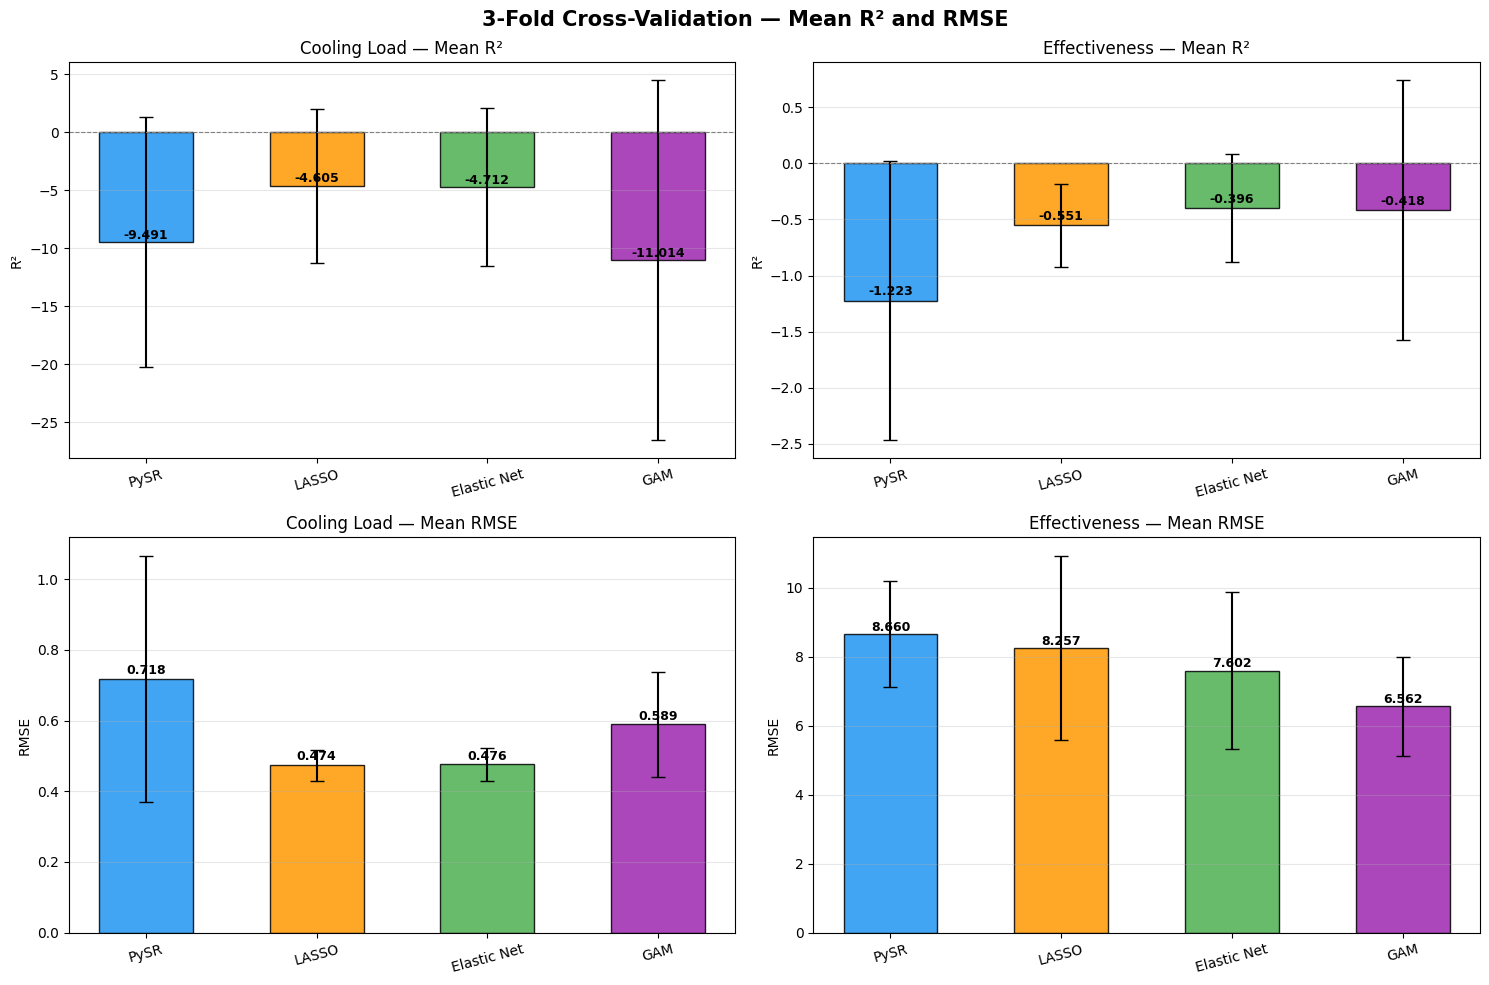

In [ ]:

pal = SEABORN_PALETTE
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("3-Fold Cross-Validation — Mean R² and RMSE", fontsize=15, fontweight='bold')

colors = [pal[0], pal[2], pal[4], pal[6]]
x_pos = np.arange(len(model_names))
bar_width = 0.55

for col, target in enumerate(['Cooling Load', 'Effectiveness']):

    means_r2 = [np.mean(cv_results[target][m]['r2']) for m in model_names]
    stds_r2  = [np.std(cv_results[target][m]['r2'])  for m in model_names]
    bars = axes[0, col].bar(x_pos, means_r2, bar_width, yerr=stds_r2,
                             color=colors, edgecolor='black', capsize=5, alpha=0.85)
    axes[0, col].set_title(f'{target} — Mean R²')
    axes[0, col].set_xticks(x_pos); axes[0, col].set_xticklabels(model_names, rotation=15)
    axes[0, col].set_ylabel('R²'); axes[0, col].axhline(0, color=pal[8], ls='--', lw=0.8)
    axes[0, col].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, means_r2):
        axes[0, col].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                          f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')


    means_rmse = [np.mean(cv_results[target][m]['rmse']) for m in model_names]
    stds_rmse  = [np.std(cv_results[target][m]['rmse'])  for m in model_names]
    bars = axes[1, col].bar(x_pos, means_rmse, bar_width, yerr=stds_rmse,
                             color=colors, edgecolor='black', capsize=5, alpha=0.85)
    axes[1, col].set_title(f'{target} — Mean RMSE')
    axes[1, col].set_xticks(x_pos); axes[1, col].set_xticklabels(model_names, rotation=15)
    axes[1, col].set_ylabel('RMSE'); axes[1, col].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, means_rmse):
        axes[1, col].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                          f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

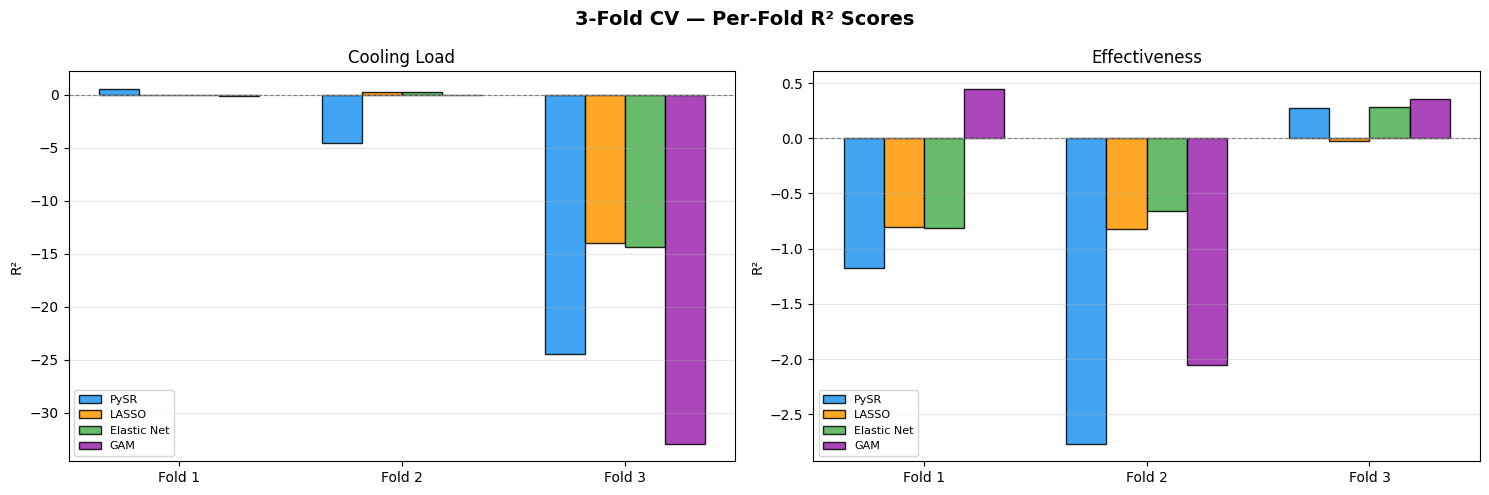

In [ ]:

pal = SEABORN_PALETTE
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("3-Fold CV — Per-Fold R² Scores", fontsize=14, fontweight='bold')

colors = [pal[0], pal[2], pal[4], pal[6]]
bar_w = 0.18
fold_labels = ['Fold 1', 'Fold 2', 'Fold 3']

for col, target in enumerate(['Cooling Load', 'Effectiveness']):
    x = np.arange(3)
    for j, model in enumerate(model_names):
        r2_vals = cv_results[target][model]['r2']
        axes[col].bar(x + j * bar_w, r2_vals, bar_w, label=model,
                      color=colors[j], edgecolor='black', alpha=0.85)
    axes[col].set_title(f'{target}')
    axes[col].set_xticks(x + bar_w * 1.5)
    axes[col].set_xticklabels(fold_labels)
    axes[col].set_ylabel('R²')
    axes[col].axhline(0, color=pal[8], ls='--', lw=0.8)
    axes[col].legend(fontsize=8)
    axes[col].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

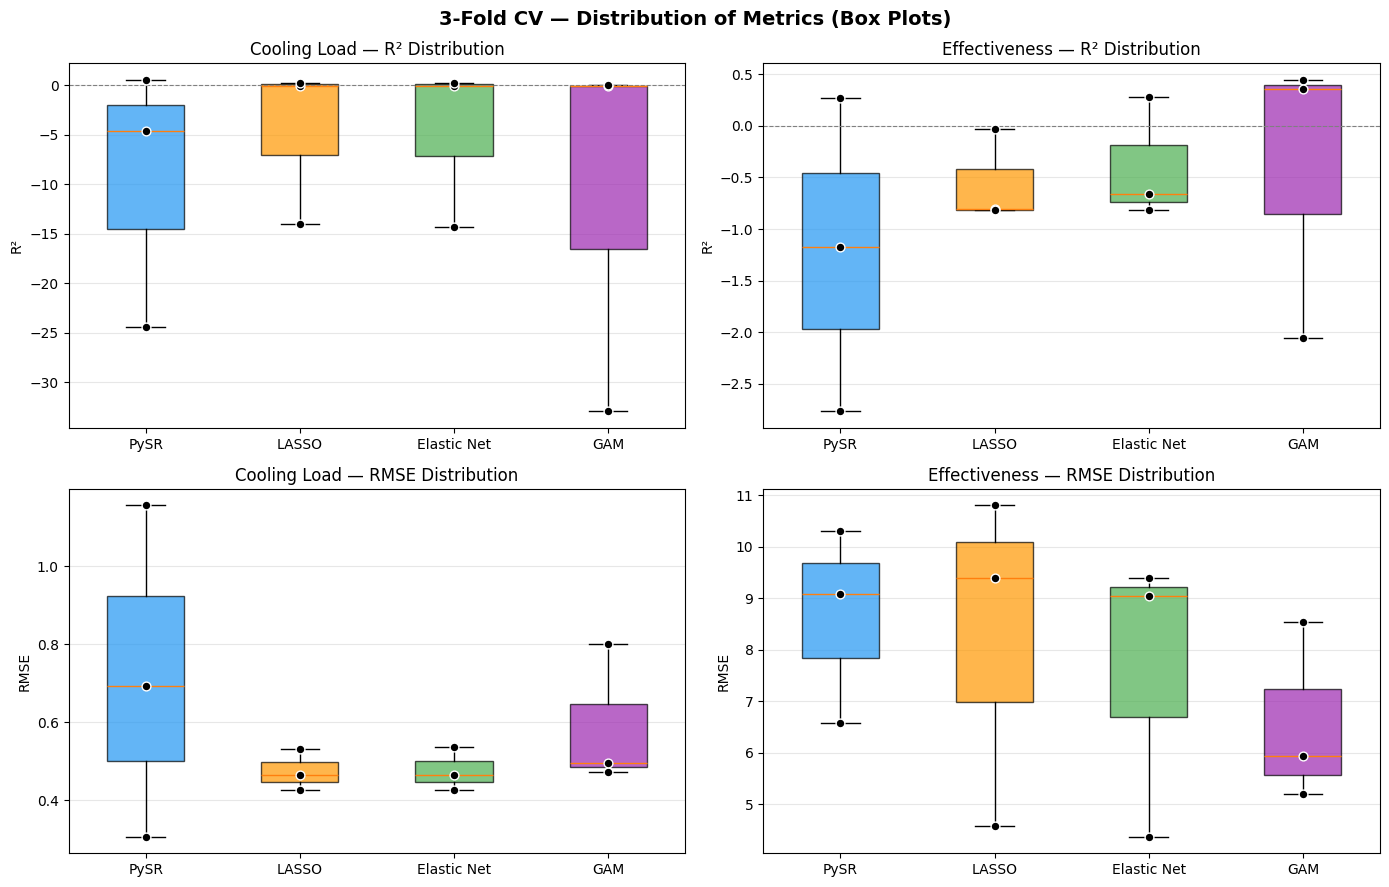

In [ ]:

pal = SEABORN_PALETTE
colors = [pal[0], pal[2], pal[4], pal[6]]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("3-Fold CV — Distribution of Metrics (Box Plots)", fontsize=14, fontweight='bold')

for col, target in enumerate(['Cooling Load', 'Effectiveness']):

    r2_data = [cv_results[target][m]['r2'] for m in model_names]
    bp1 = axes[0, col].boxplot(r2_data, labels=model_names, patch_artist=True, widths=0.5)
    for patch, c in zip(bp1['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)

    for i, vals in enumerate(r2_data):
        axes[0, col].scatter([i+1]*len(vals), vals, color=pal[9], zorder=5, s=40, edgecolors='white')
    axes[0, col].set_title(f'{target} — R² Distribution')
    axes[0, col].set_ylabel('R²'); axes[0, col].grid(axis='y', alpha=0.3)
    axes[0, col].axhline(0, color=pal[8], ls='--', lw=0.8)


    rmse_data = [cv_results[target][m]['rmse'] for m in model_names]
    bp2 = axes[1, col].boxplot(rmse_data, labels=model_names, patch_artist=True, widths=0.5)
    for patch, c in zip(bp2['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    for i, vals in enumerate(rmse_data):
        axes[1, col].scatter([i+1]*len(vals), vals, color=pal[9], zorder=5, s=40, edgecolors='white')
    axes[1, col].set_title(f'{target} — RMSE Distribution')
    axes[1, col].set_ylabel('RMSE'); axes[1, col].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

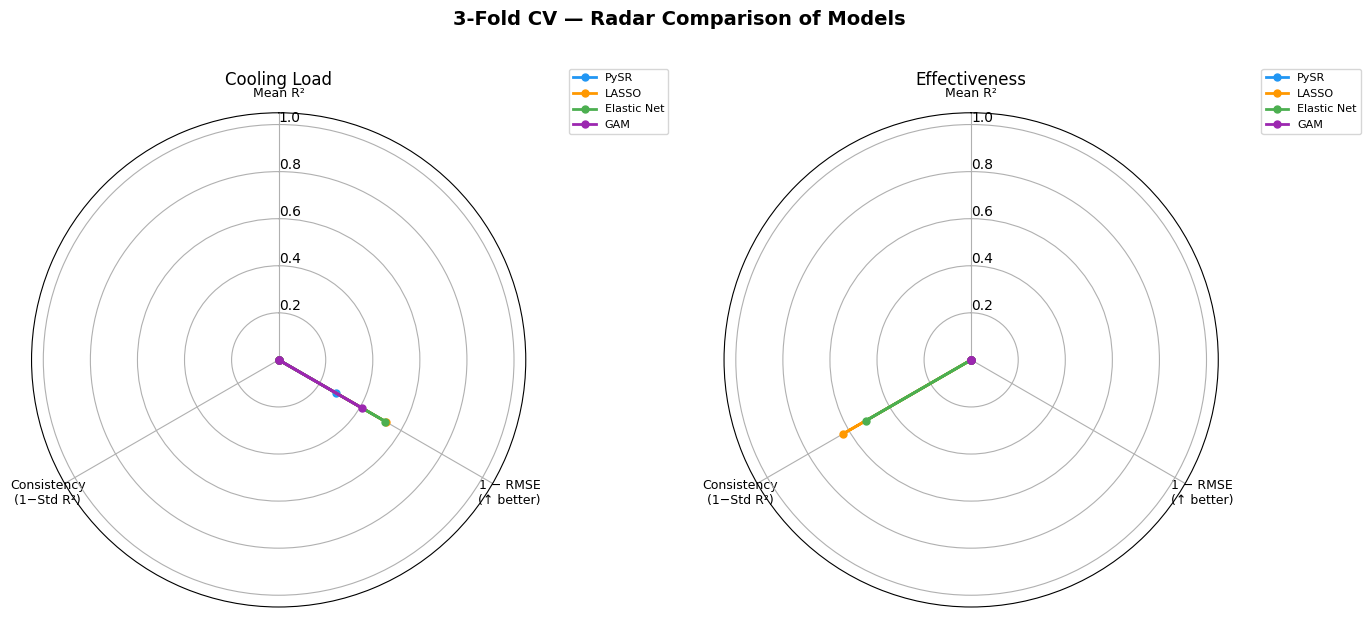


✅ All CV visualizations complete.


In [ ]:

from matplotlib.patches import FancyBboxPatch

pal = SEABORN_PALETTE
colors = [pal[0], pal[2], pal[4], pal[6]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))
fig.suptitle("3-Fold CV — Radar Comparison of Models", fontsize=14, fontweight='bold', y=1.02)


metric_labels = ['Mean R²', '1 − RMSE\n(↑ better)', 'Consistency\n(1−Std R²)']

for col, target in enumerate(['Cooling Load', 'Effectiveness']):
    values_per_model = []
    for m in model_names:
        mean_r2   = np.mean(cv_results[target][m]['r2'])
        mean_rmse = np.mean(cv_results[target][m]['rmse'])
        std_r2    = np.std(cv_results[target][m]['r2'])

        values_per_model.append([
            max(0, mean_r2),
            max(0, 1 - mean_rmse),
            max(0, 1 - std_r2),
        ])

    N = len(metric_labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    ax = axes[col]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)
    ax.set_title(target, fontsize=12, pad=20)

    for j, m in enumerate(model_names):
        vals = values_per_model[j] + values_per_model[j][:1]
        ax.plot(angles, vals, 'o-', color=colors[j], label=m, lw=2, markersize=5)
        ax.fill(angles, vals, color=colors[j], alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.show()

print("\n✅ All CV visualizations complete.")

In [ ]:
!pip install feyn

In [10]:
import feyn


ql = feyn.QLattice(random_seed=42)


features = ['WFR_L_min', 'WIT_degC', 'AFR_L_s']
target = 'Effectiveness_pct'




models = ql.auto_run(
    data=df_final,
    output_name=target,
    stypes={f: 'num' for f in features},
    max_complexity=5,
    criterion='bic',
    n_epochs=20
)


best_model = models[0]
best_model.plot(df_final, df_final)
print(best_model.sympify())

6.42926*CoolingLoadkW - 13.0198*WFRLmin + 66.4031


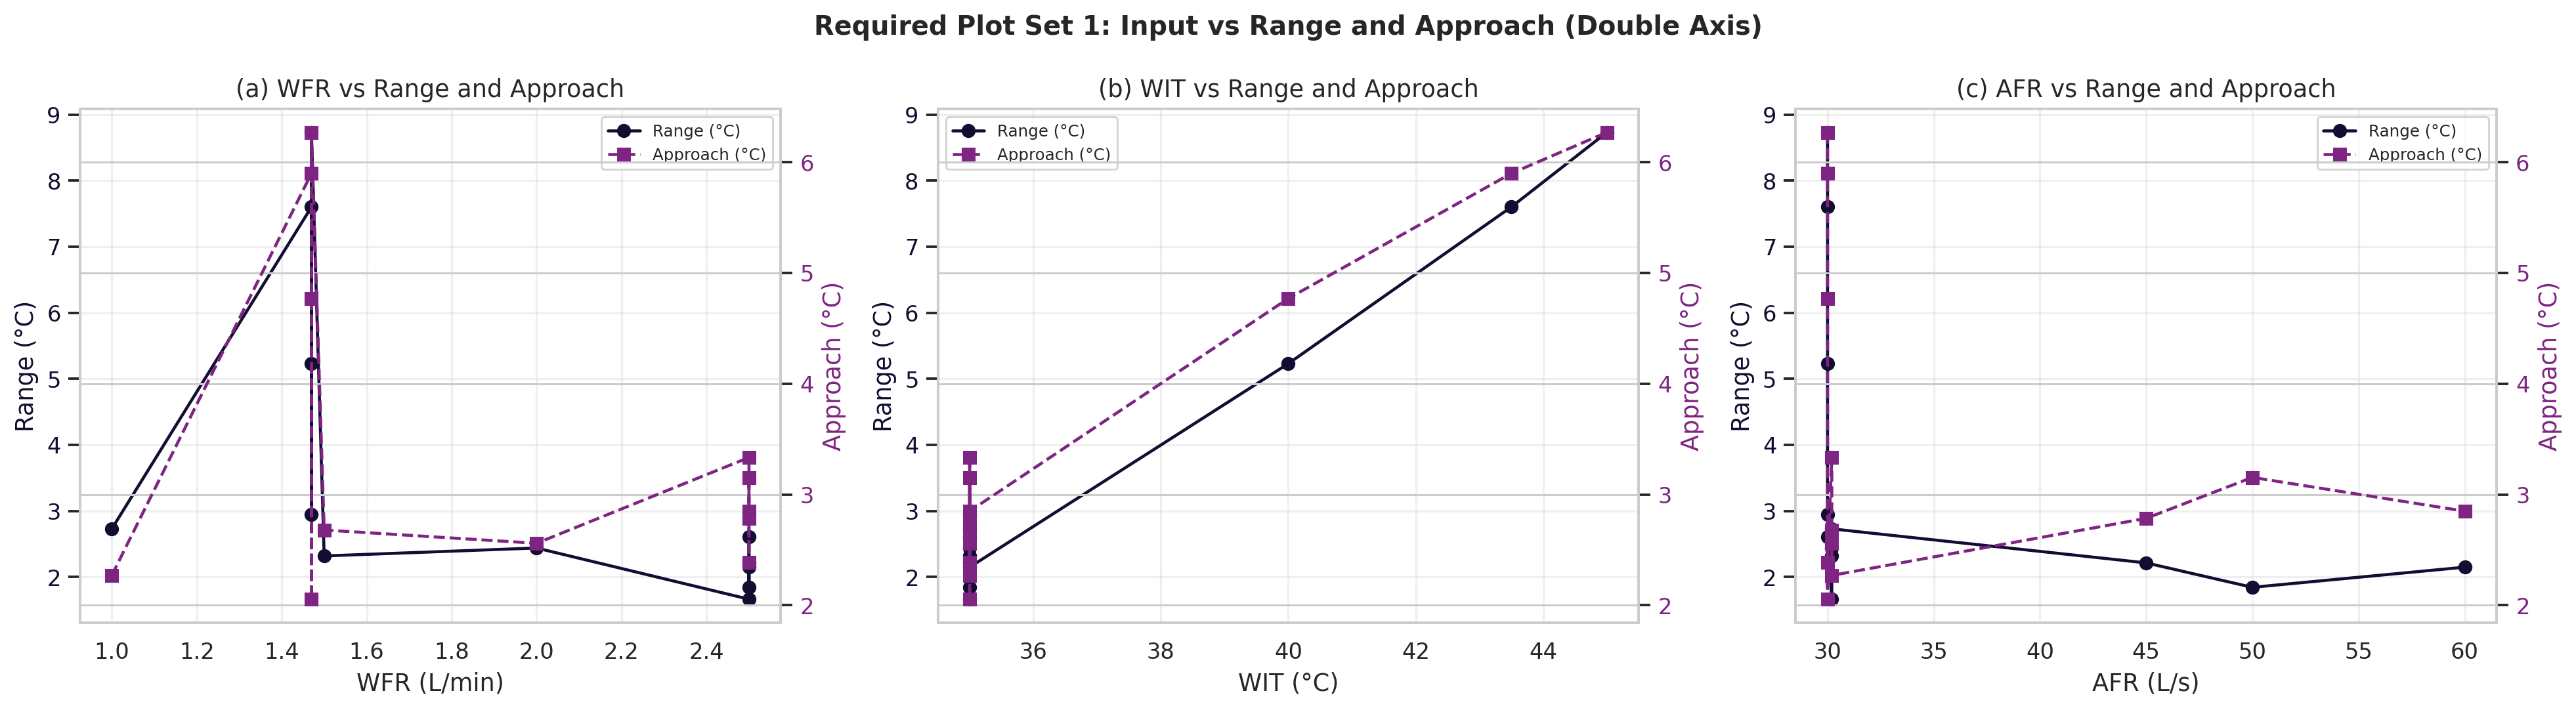

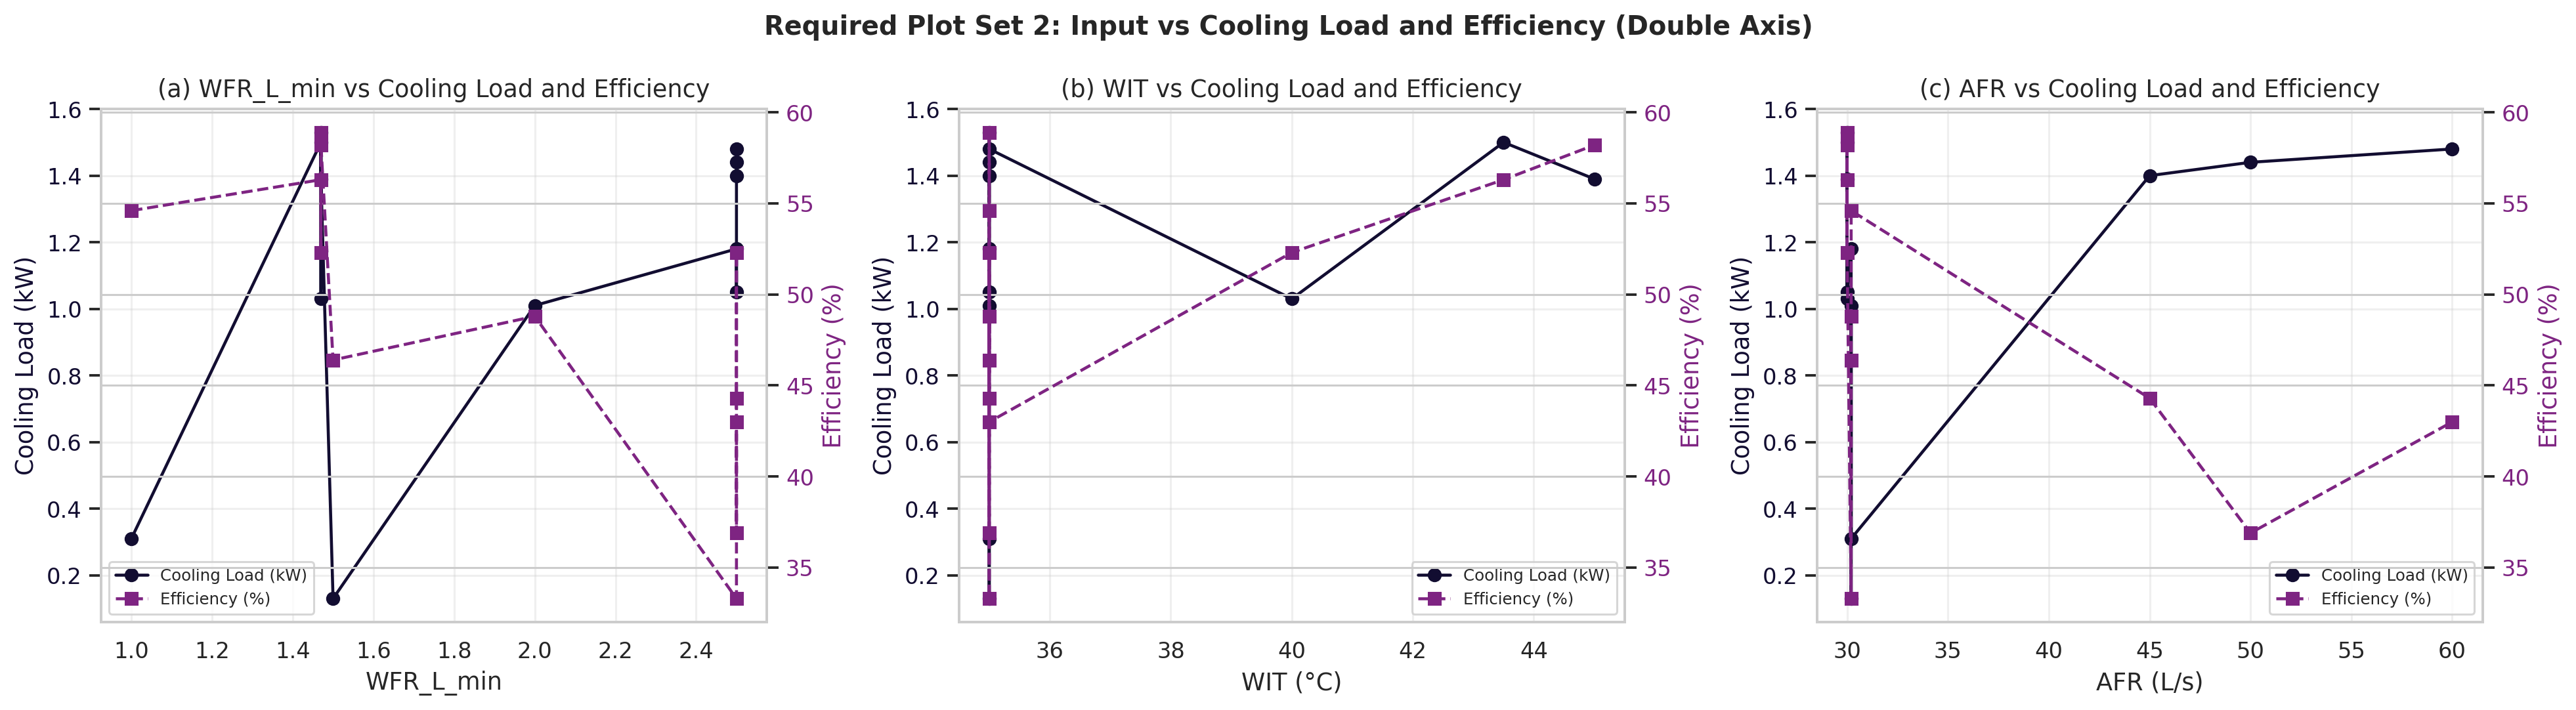

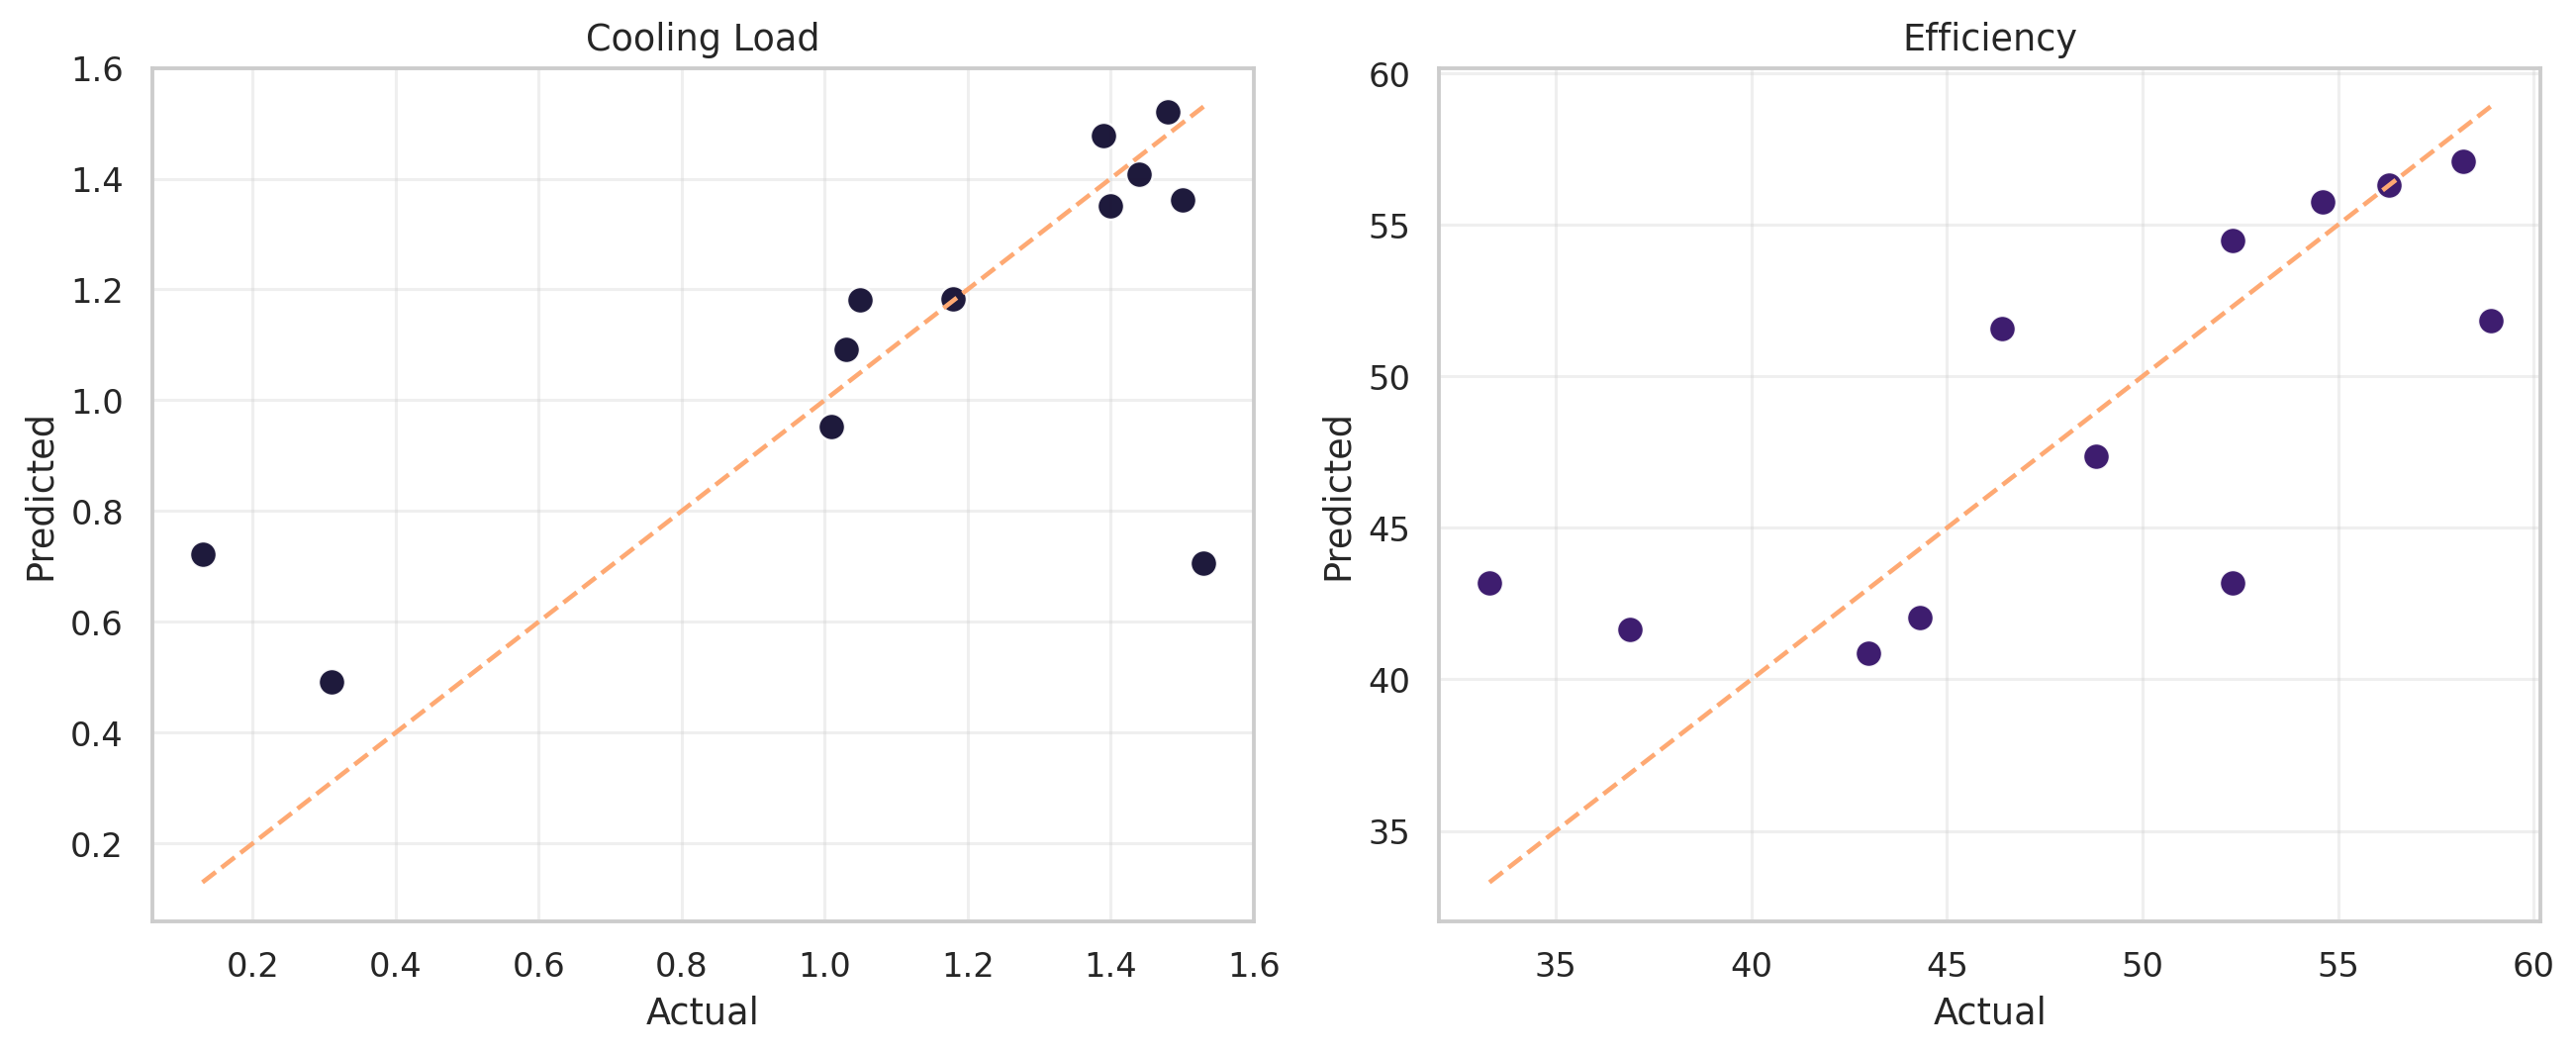

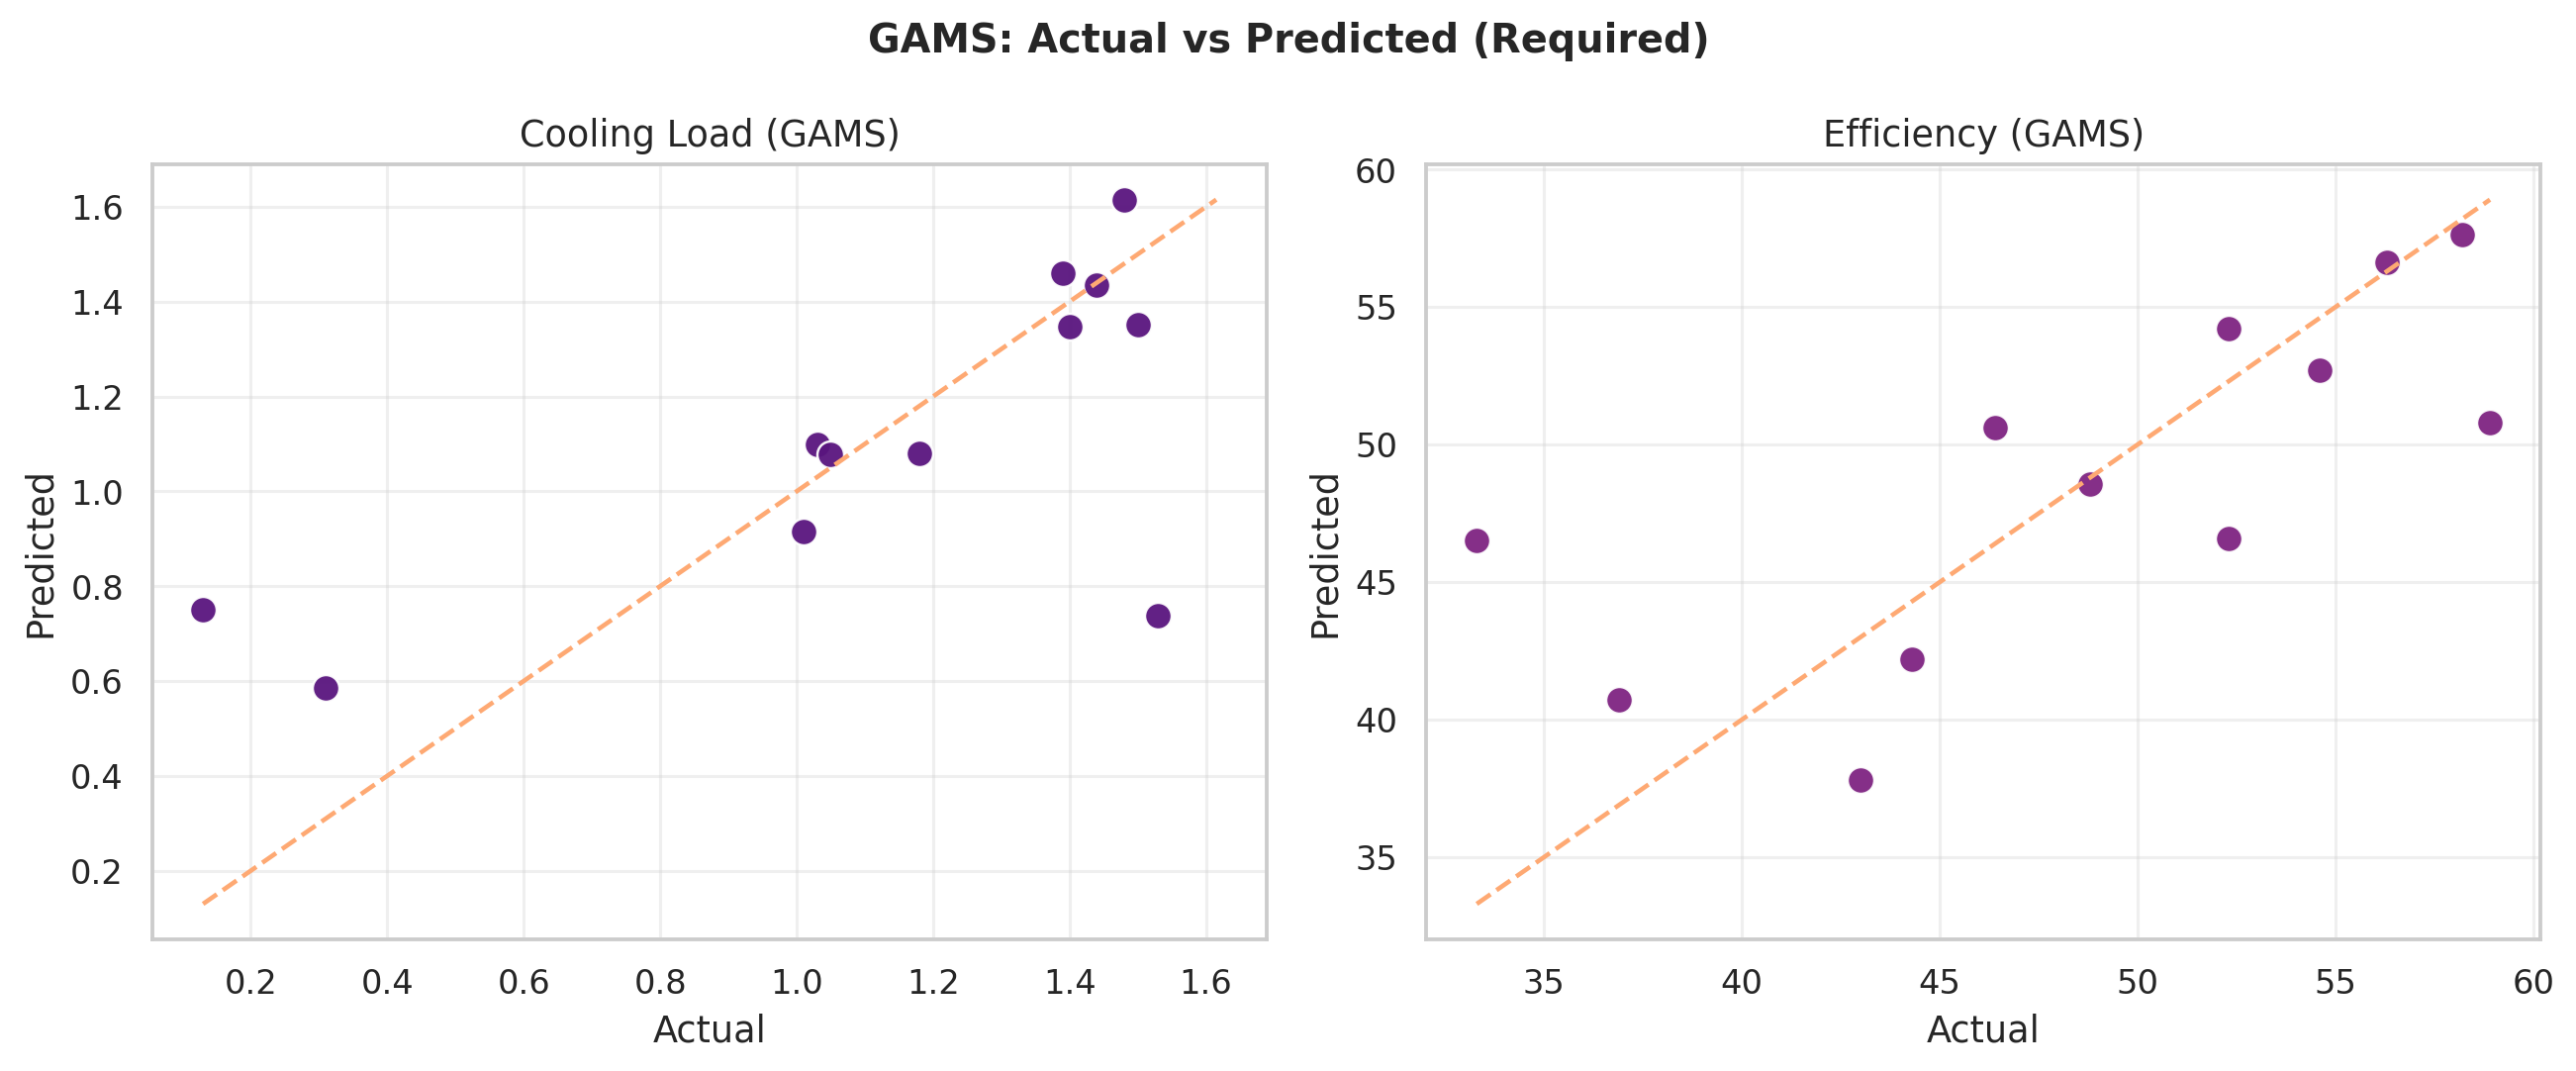

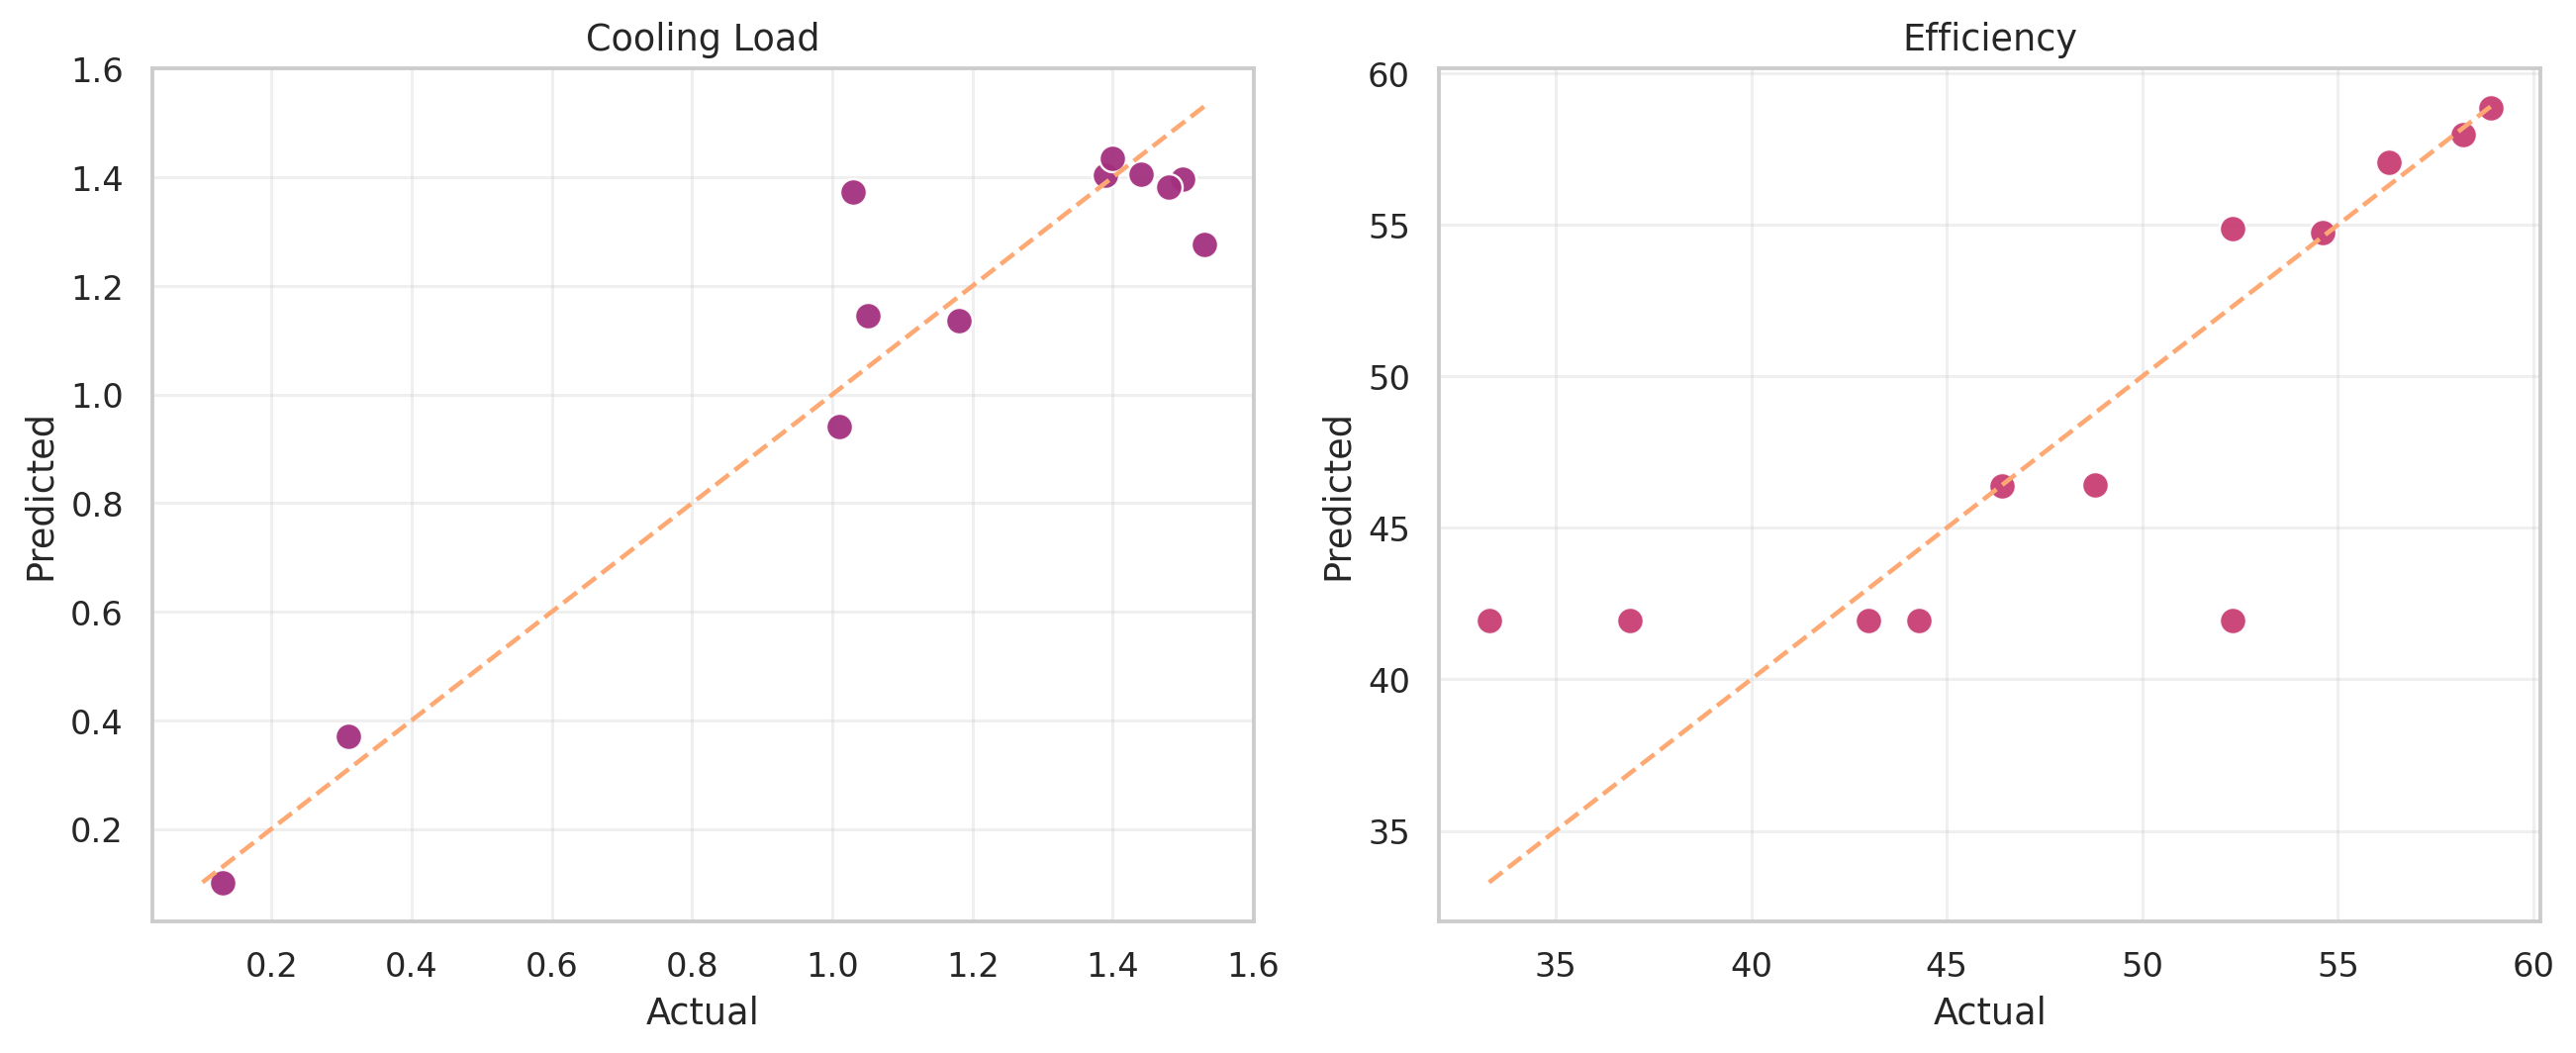

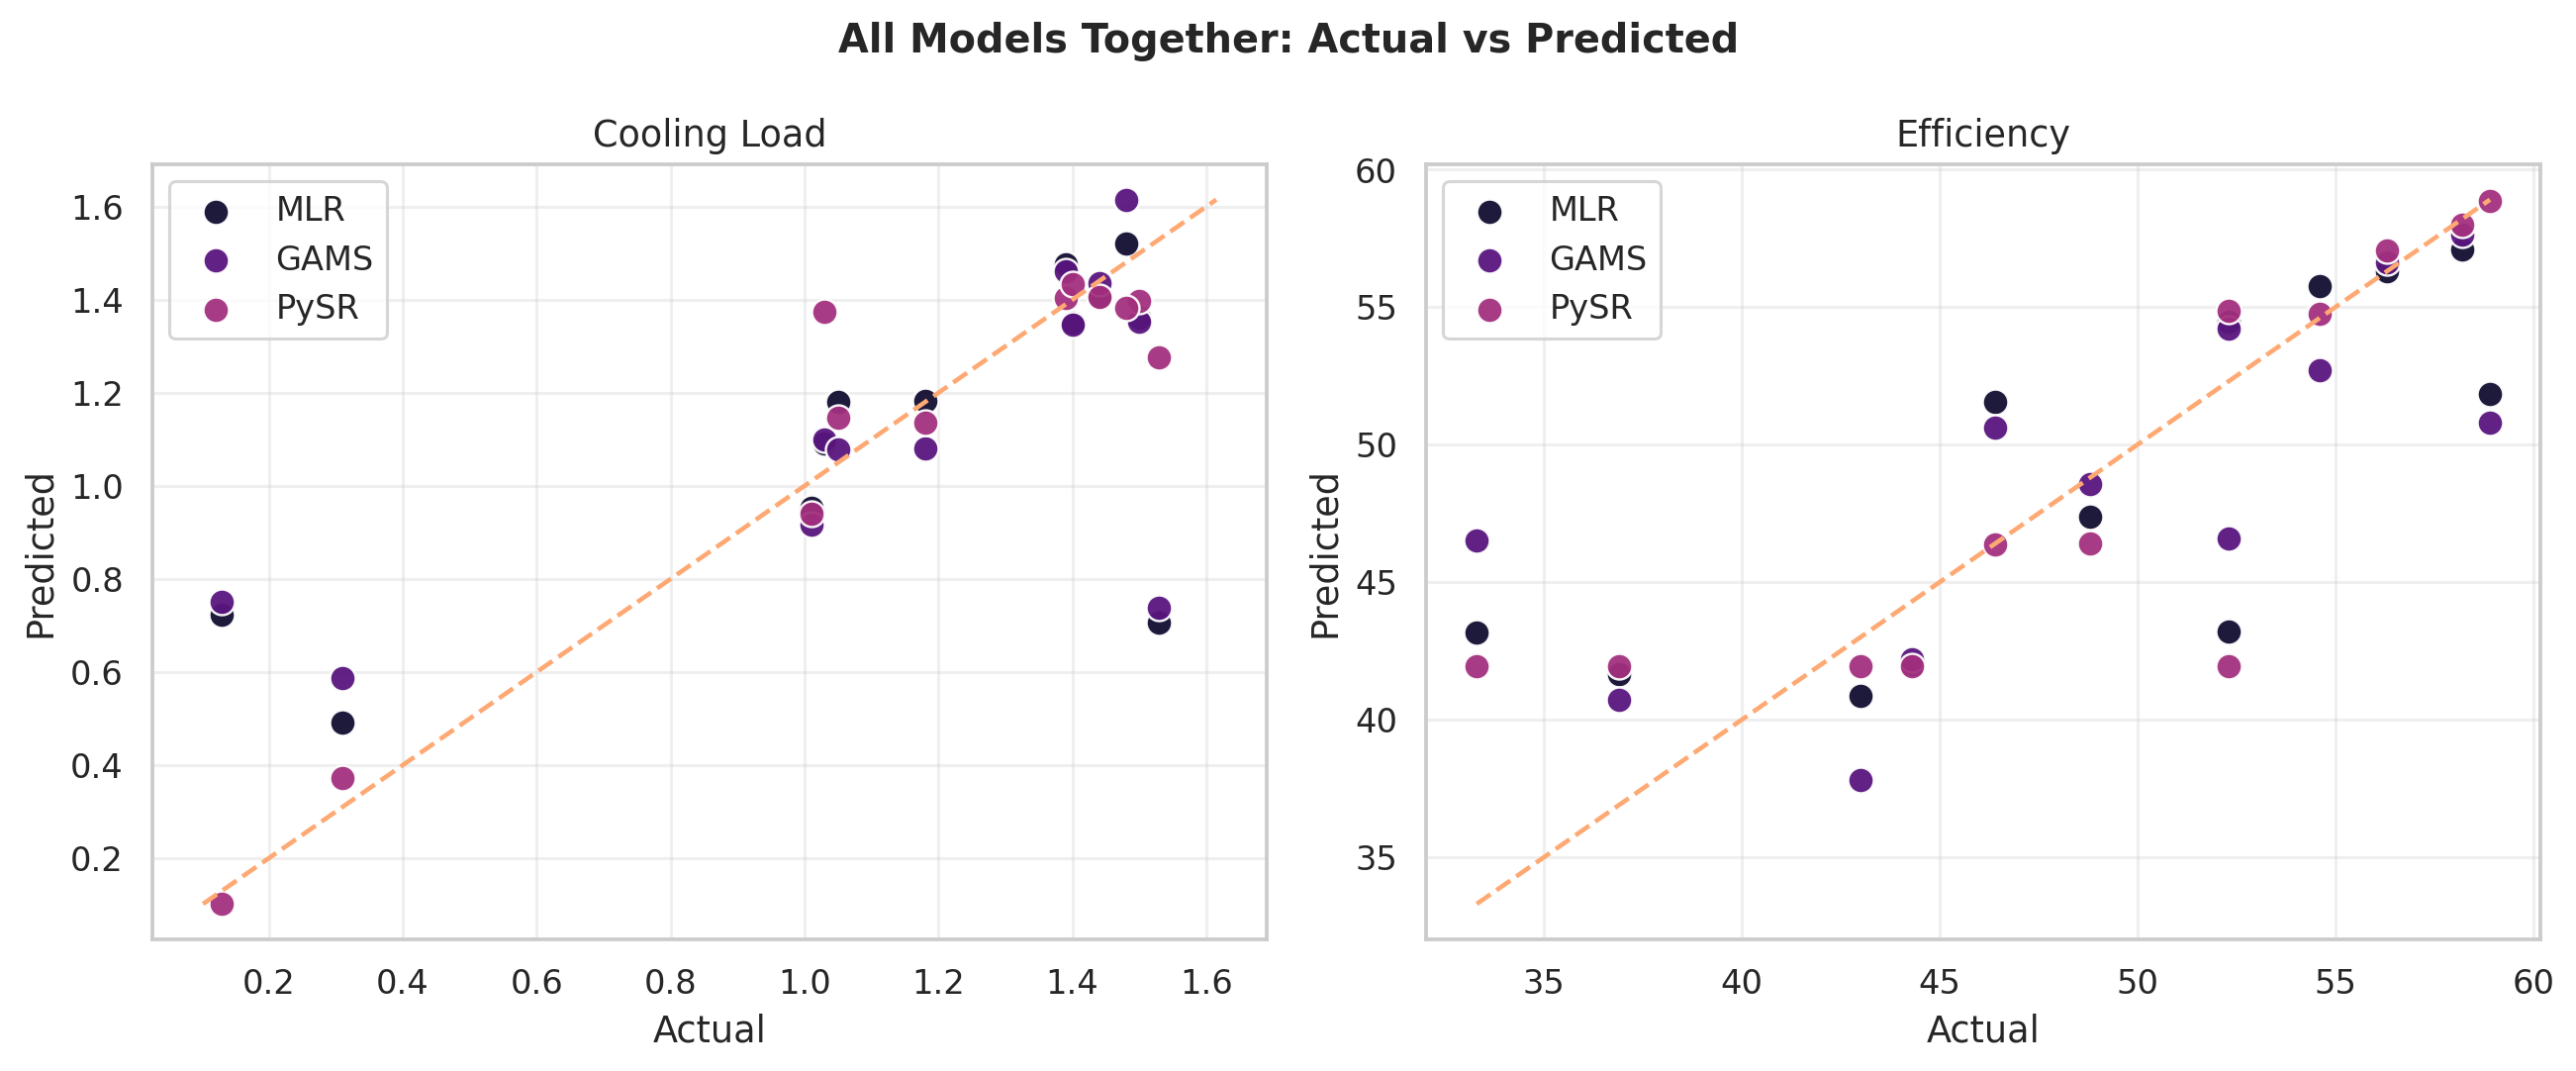

Final developed equations and metrics (required):


,Model,Target,Equation,R2,RMSE
0,MLR,Cooling Load,Cooling_Load = -3.006680 +0.460945*WFR +0.077031*WIT +0.011321*AFR,0.5261,0.3053
1,MLR,Efficiency,Efficiency = 47.989193 -8.384705*WFR +0.527973*WIT -0.077229*AFR,0.5999,4.9884
2,GAMS,Cooling Load,Cooling_Load = intercept + s(WFR) + s(WIT) + s(AFR),0.5077,0.3112
3,GAMS,Efficiency,Efficiency = intercept + s(WFR) + s(WIT) + s(AFR),0.5382,5.3592
4,PySR,Cooling Load,(0.18512224 / (-20.90176 * (WFR + -1.4857113))) + sqrt((WFR - 0.6671222) - (WFR / (WIT - AFR))),0.9045,0.1371
5,PySR,Efficiency,(1.9930205 / (WIT + (WFR * -23.637854))) + sqrt((108.151215 + (WFR * -23.081179)) * WIT),0.6959,4.3491


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from pygam import LinearGAM, s
import seaborn as sns


plt.rcParams['figure.dpi'] = 220
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid", font_scale=1.0)
SEABORN_PALETTE = sns.color_palette("magma", n_colors=10)
pal = SEABORN_PALETTE


try:
    from pysr import PySRRegressor
    _pysr_available = True
except Exception as _e:
    _pysr_available = False
    print("PySR not available in this environment. Install with: pip install pysr")




df_plot = df_final.copy()
X = df_plot[['WFR_L_min', 'WIT_degC', 'AFR_L_s']].values
y_cl = df_plot['Cooling_Load_kW'].values
y_eff = df_plot['Effectiveness_pct'].values
feature_names = ['WFR', 'WIT', 'AFR']





if 'Range_degC' not in df_plot.columns or 'Approach_degC' not in df_plot.columns:
    WBT_REF = 30.0
    delta = (df_plot['WIT_degC'] - WBT_REF).clip(lower=1e-6)
    eff_frac = (df_plot['Effectiveness_pct'] / 100.0).clip(0, 1)
    df_plot['Range_degC'] = eff_frac * delta
    df_plot['Approach_degC'] = (1 - eff_frac) * delta

x_wef_col = 'WEF' if 'WEF' in df_plot.columns else 'WFR_L_min'




def _dual_axis_plot(ax, x, y_left, y_right, left_label, right_label, x_label, title):
    order = np.argsort(x)
    xs = np.asarray(x)[order]
    yl = np.asarray(y_left)[order]
    yr = np.asarray(y_right)[order]

    ax.plot(xs, yl, 'o-', color=pal[0], label=left_label, markersize=6)
    ax.set_xlabel(x_label)
    ax.set_ylabel(left_label, color=pal[0])
    ax.tick_params(axis='y', labelcolor=pal[0])
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(xs, yr, 's--', color=pal[3], label=right_label, markersize=6)
    ax2.set_ylabel(right_label, color=pal[3])
    ax2.tick_params(axis='y', labelcolor=pal[3])
    ax.set_title(title)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='best', fontsize=8)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Required Plot Set 1: Input vs Range and Approach (Double Axis)', fontsize=13, fontweight='bold')

_dual_axis_plot(axs[0], df_plot['WFR_L_min'], df_plot['Range_degC'], df_plot['Approach_degC'], 'Range (°C)', 'Approach (°C)', 'WFR (L/min)', '(a) WFR vs Range and Approach')
_dual_axis_plot(axs[1], df_plot['WIT_degC'], df_plot['Range_degC'], df_plot['Approach_degC'], 'Range (°C)', 'Approach (°C)', 'WIT (°C)', '(b) WIT vs Range and Approach')
_dual_axis_plot(axs[2], df_plot['AFR_L_s'], df_plot['Range_degC'], df_plot['Approach_degC'], 'Range (°C)', 'Approach (°C)', 'AFR (L/s)', '(c) AFR vs Range and Approach')

plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Required Plot Set 2: Input vs Cooling Load and Efficiency (Double Axis)', fontsize=13, fontweight='bold')

_dual_axis_plot(axs[0], df_plot[x_wef_col], df_plot['Cooling_Load_kW'], df_plot['Effectiveness_pct'], 'Cooling Load (kW)', 'Efficiency (%)', f'{x_wef_col}', f'(a) {x_wef_col} vs Cooling Load and Efficiency')
_dual_axis_plot(axs[1], df_plot['WIT_degC'], df_plot['Cooling_Load_kW'], df_plot['Effectiveness_pct'], 'Cooling Load (kW)', 'Efficiency (%)', 'WIT (°C)', '(b) WIT vs Cooling Load and Efficiency')
_dual_axis_plot(axs[2], df_plot['AFR_L_s'], df_plot['Cooling_Load_kW'], df_plot['Effectiveness_pct'], 'Cooling Load (kW)', 'Efficiency (%)', 'AFR (L/s)', '(c) AFR vs Cooling Load and Efficiency')

plt.tight_layout(); plt.show()




def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

mlr_cl = LinearRegression().fit(X, y_cl)
mlr_eff = LinearRegression().fit(X, y_eff)
y_cl_pred_mlr = mlr_cl.predict(X)
y_eff_pred_mlr = mlr_eff.predict(X)

def mlr_equation(model, target_name):
    b0 = model.intercept_
    c1, c2, c3 = model.coef_
    return f"{target_name} = {b0:.6f} {c1:+.6f}*WFR {c2:+.6f}*WIT {c3:+.6f}*AFR"

eq_mlr_cl = mlr_equation(mlr_cl, 'Cooling_Load')
eq_mlr_eff = mlr_equation(mlr_eff, 'Efficiency')

if 'gam_1' in globals() and 'gam_2' in globals():
    gams_cl = gam_1
    gams_eff = gam_2
else:
    gams_cl = LinearGAM(s(0, n_splines=5) + s(1, n_splines=5) + s(2, n_splines=5)).gridsearch(X, y_cl, progress=False)
    gams_eff = LinearGAM(s(0, n_splines=5) + s(1, n_splines=5) + s(2, n_splines=5)).gridsearch(X, y_eff, progress=False)

y_cl_pred_gams = gams_cl.predict(X)
y_eff_pred_gams = gams_eff.predict(X)
eq_gams_cl = 'Cooling_Load = intercept + s(WFR) + s(WIT) + s(AFR)'
eq_gams_eff = 'Efficiency = intercept + s(WFR) + s(WIT) + s(AFR)'

pysr_ok = False
if _pysr_available:
    try:
        if 'pysr_model_1' in globals() and 'pysr_model_2' in globals():
            psr_cl = pysr_model_1
            psr_eff = pysr_model_2
        else:
            psr_cl = PySRRegressor(niterations=120, binary_operators=['+', '-', '*', '/'], unary_operators=['square', 'sqrt', 'abs'], populations=12, population_size=30, maxsize=20, parsimony=0.01, random_state=42, deterministic=True, procs=0, multithreading=False, temp_equation_file=True, verbosity=0)
            psr_eff = PySRRegressor(niterations=120, binary_operators=['+', '-', '*', '/'], unary_operators=['square', 'sqrt', 'abs'], populations=12, population_size=30, maxsize=20, parsimony=0.01, random_state=42, deterministic=True, procs=0, multithreading=False, temp_equation_file=True, verbosity=0)
            psr_cl.fit(X, y_cl, variable_names=feature_names)
            psr_eff.fit(X, y_eff, variable_names=feature_names)

        y_cl_pred_pysr = psr_cl.predict(X)
        y_eff_pred_pysr = psr_eff.predict(X)
        eq_pysr_cl = str(psr_cl.get_best()['equation'])
        eq_pysr_eff = str(psr_eff.get_best()['equation'])
        pysr_ok = True
    except Exception as ex:
        print(f'PySR training/prediction failed: {ex}')




def scatter_actual_vs_pred(ax, y_true, y_pred, title, color):
    ax.scatter(y_true, y_pred, color=color, s=78, alpha=0.95, edgecolor='white', linewidth=0.8)
    y_min = min(np.min(y_true), np.min(y_pred))
    y_max = max(np.max(y_true), np.max(y_pred))
    ax.plot([y_min, y_max], [y_min, y_max], linestyle='--', color=pal[8], lw=1.5)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter_actual_vs_pred(axes[0], y_cl, y_cl_pred_mlr, 'Cooling Load', pal[0])
scatter_actual_vs_pred(axes[1], y_eff, y_eff_pred_mlr, 'Efficiency', pal[1])
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('GAMS: Actual vs Predicted (Required)', fontsize=13, fontweight='bold')
scatter_actual_vs_pred(axes[0], y_cl, y_cl_pred_gams, 'Cooling Load (GAMS)', pal[2])
scatter_actual_vs_pred(axes[1], y_eff, y_eff_pred_gams, 'Efficiency (GAMS)', pal[3])
plt.tight_layout(); plt.show()

if pysr_ok:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    scatter_actual_vs_pred(axes[0], y_cl, y_cl_pred_pysr, 'Cooling Load', pal[4])
    scatter_actual_vs_pred(axes[1], y_eff, y_eff_pred_pysr, 'Efficiency', pal[5])
    plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('All Models Together: Actual vs Predicted', fontsize=13, fontweight='bold')

axes[0].scatter(y_cl, y_cl_pred_mlr, label='MLR', s=72, alpha=0.95, color=pal[0], edgecolor='white', linewidth=0.8)
axes[0].scatter(y_cl, y_cl_pred_gams, label='GAMS', s=72, alpha=0.95, color=pal[2], edgecolor='white', linewidth=0.8)
if pysr_ok:
    axes[0].scatter(y_cl, y_cl_pred_pysr, label='PySR', s=72, alpha=0.95, color=pal[4], edgecolor='white', linewidth=0.8)
line_min = min(y_cl.min(), y_cl_pred_mlr.min(), y_cl_pred_gams.min(), y_cl_pred_pysr.min() if pysr_ok else y_cl_pred_gams.min())
line_max = max(y_cl.max(), y_cl_pred_mlr.max(), y_cl_pred_gams.max(), y_cl_pred_pysr.max() if pysr_ok else y_cl_pred_gams.max())
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle='--', color=pal[8], lw=1.5)
axes[0].set_title('Cooling Load'); axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].scatter(y_eff, y_eff_pred_mlr, label='MLR', s=72, alpha=0.95, color=pal[0], edgecolor='white', linewidth=0.8)
axes[1].scatter(y_eff, y_eff_pred_gams, label='GAMS', s=72, alpha=0.95, color=pal[2], edgecolor='white', linewidth=0.8)
if pysr_ok:
    axes[1].scatter(y_eff, y_eff_pred_pysr, label='PySR', s=72, alpha=0.95, color=pal[4], edgecolor='white', linewidth=0.8)
line_min = min(y_eff.min(), y_eff_pred_mlr.min(), y_eff_pred_gams.min(), y_eff_pred_pysr.min() if pysr_ok else y_eff_pred_gams.min())
line_max = max(y_eff.max(), y_eff_pred_mlr.max(), y_eff_pred_gams.max(), y_eff_pred_pysr.max() if pysr_ok else y_eff_pred_gams.max())
axes[1].plot([line_min, line_max], [line_min, line_max], linestyle='--', color=pal[8], lw=1.5)
axes[1].set_title('Efficiency'); axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted'); axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()




rows = []
def add_row(model_name, target_name, equation_text, y_true, y_pred):
    rows.append({'Model': model_name, 'Target': target_name, 'Equation': equation_text, 'R2': r2_score(y_true, y_pred), 'RMSE': rmse(y_true, y_pred)})

add_row('MLR', 'Cooling Load', eq_mlr_cl, y_cl, y_cl_pred_mlr)
add_row('MLR', 'Efficiency', eq_mlr_eff, y_eff, y_eff_pred_mlr)
add_row('GAMS', 'Cooling Load', eq_gams_cl, y_cl, y_cl_pred_gams)
add_row('GAMS', 'Efficiency', eq_gams_eff, y_eff, y_eff_pred_gams)
if pysr_ok:
    add_row('PySR', 'Cooling Load', eq_pysr_cl, y_cl, y_cl_pred_pysr)
    add_row('PySR', 'Efficiency', eq_pysr_eff, y_eff, y_eff_pred_pysr)

final_table = pd.DataFrame(rows)
print('Final developed equations and metrics (required):')
display(final_table.style.format({'R2': '{:.4f}', 'RMSE': '{:.4f}'}))

### 5.1 Add FEYN model to required plots and final table

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.0)
SEABORN_PALETTE = sns.color_palette(sns.diverging_palette(230, 20, n=10))
pal = SEABORN_PALETTE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns


plt.rcParams['figure.dpi'] = 220
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'Times New Roman'
sns.set_theme(style="whitegrid", font_scale=1.0, font='Times New Roman')
SEABORN_PALETTE = sns.color_palette("colorblind", n_colors=10)
pal = SEABORN_PALETTE

feyn_ok = False
feature_names_feyn = ['WFR_L_min', 'WIT_degC', 'AFR_L_s']

def _to_1d_pred(pred_obj):
    if isinstance(pred_obj, pd.DataFrame):
        return pred_obj.iloc[:, 0].to_numpy()
    if isinstance(pred_obj, pd.Series):
        return pred_obj.to_numpy()
    return np.asarray(pred_obj).reshape(-1)

try:
    import feyn

    ql_local = feyn.QLattice(random_seed=42)


    train_cl = df_final[feature_names_feyn + ['Cooling_Load_kW']].copy()
    train_eff = df_final[feature_names_feyn + ['Effectiveness_pct']].copy()

    models_cl = ql_local.auto_run(
        data=train_cl,
        output_name='Cooling_Load_kW',
        stypes={f: 'num' for f in feature_names_feyn},
        max_complexity=3,
        criterion='bic',
        n_epochs=20,
    )
    feyn_model_cl = models_cl[0]

    models_eff = ql_local.auto_run(
        data=train_eff,
        output_name='Effectiveness_pct',
        stypes={f: 'num' for f in feature_names_feyn},
        max_complexity=3,
        criterion='bic',
        n_epochs=20,
    )
    feyn_model_eff = models_eff[0]


    x_pred = df_final[feature_names_feyn].copy()
    y_cl_pred_feyn = _to_1d_pred(feyn_model_cl.predict(x_pred))
    y_eff_pred_feyn = _to_1d_pred(feyn_model_eff.predict(x_pred))

    eq_feyn_cl = str(feyn_model_cl.sympify())
    eq_feyn_eff = str(feyn_model_eff.sympify())
    feyn_ok = True

except Exception as ex:
    print(f"FEYN not available or failed: {ex}")

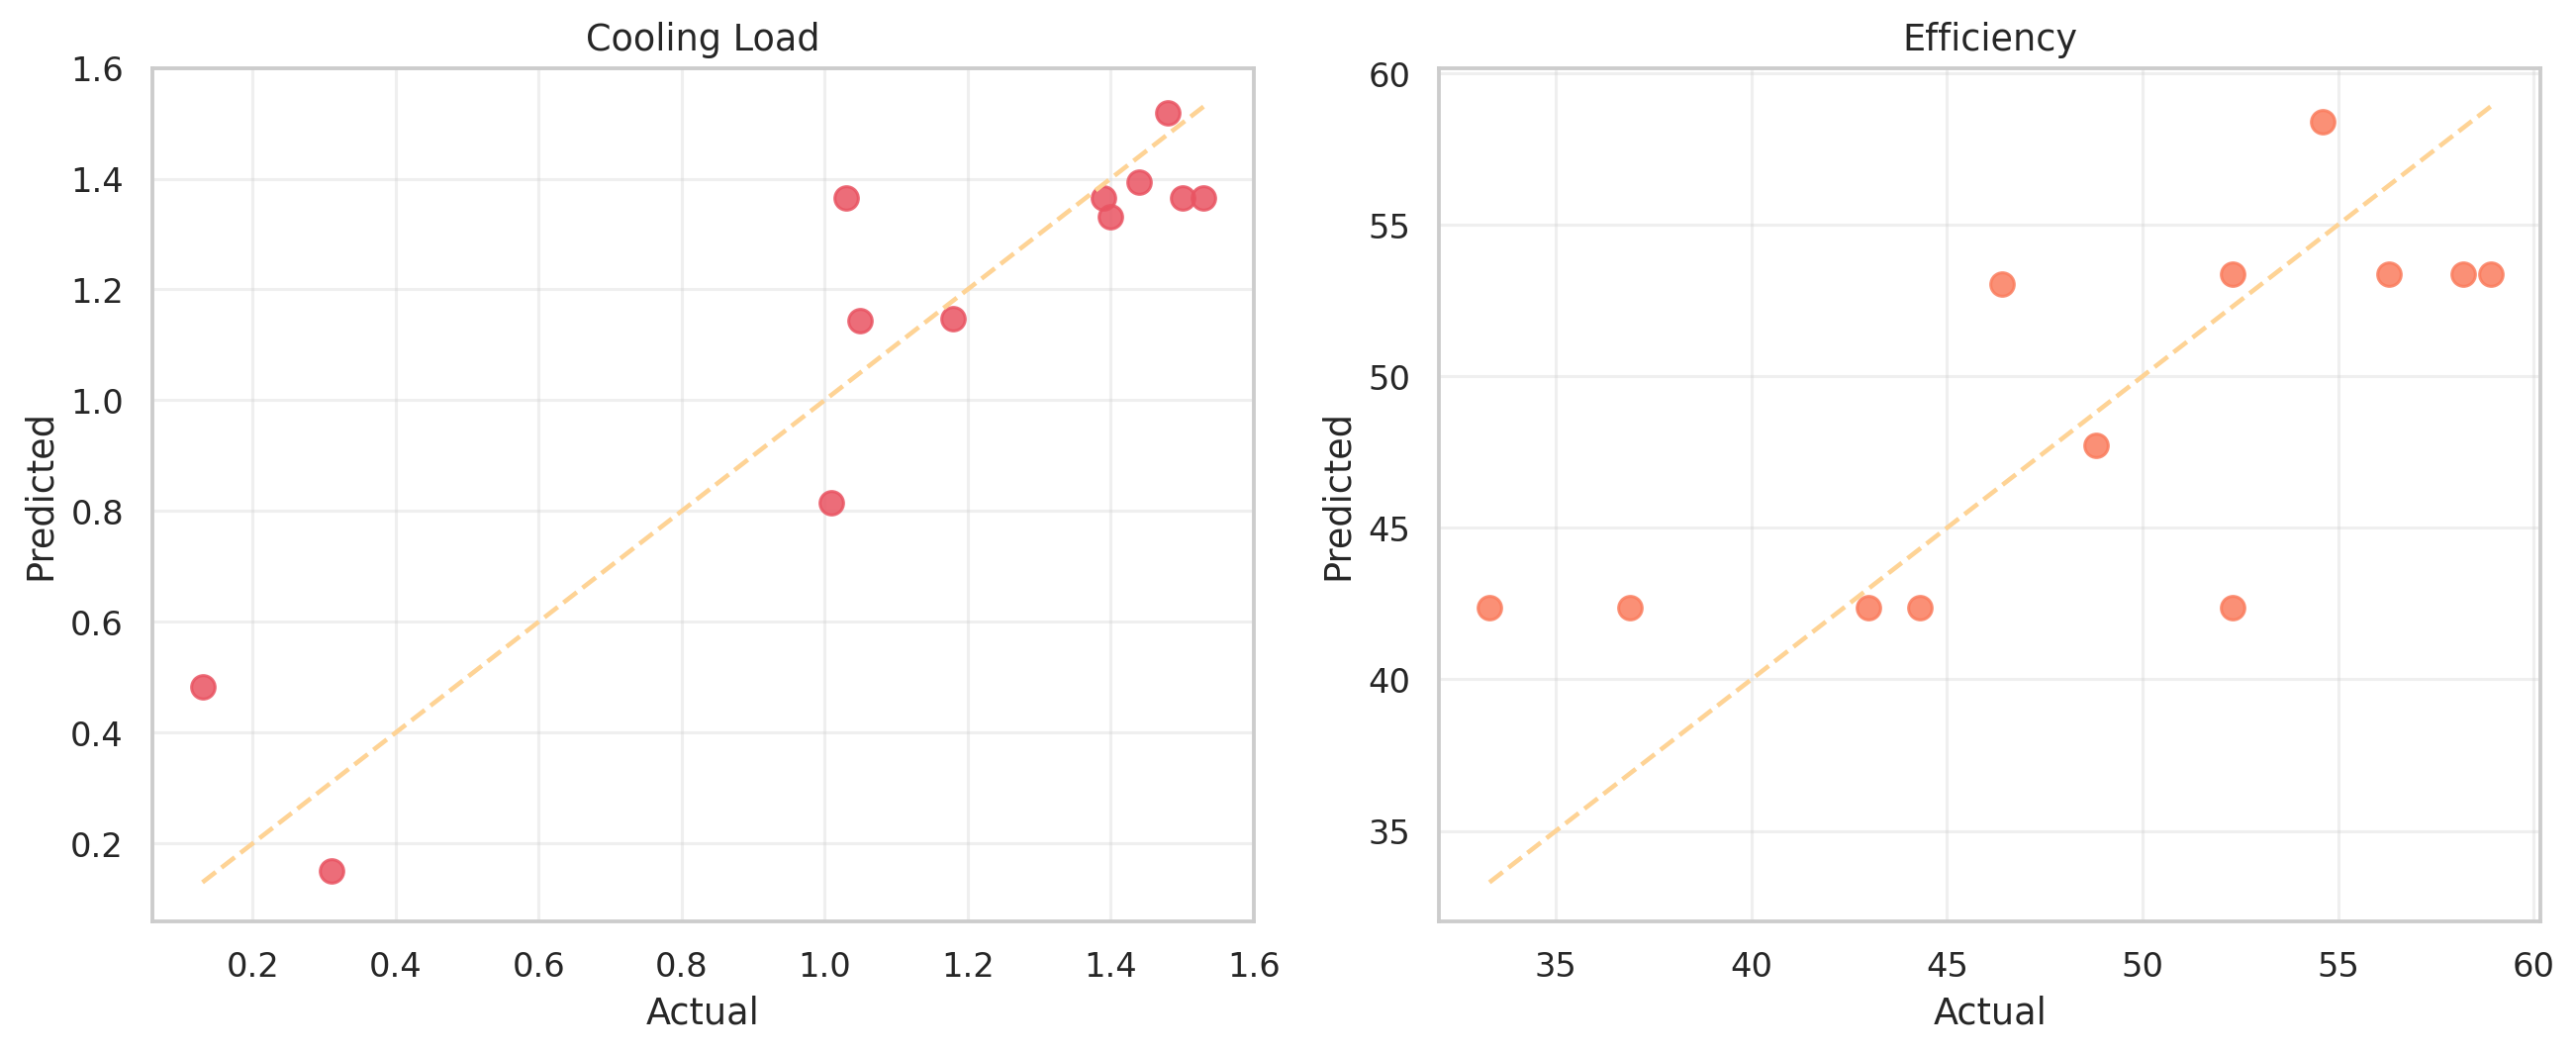

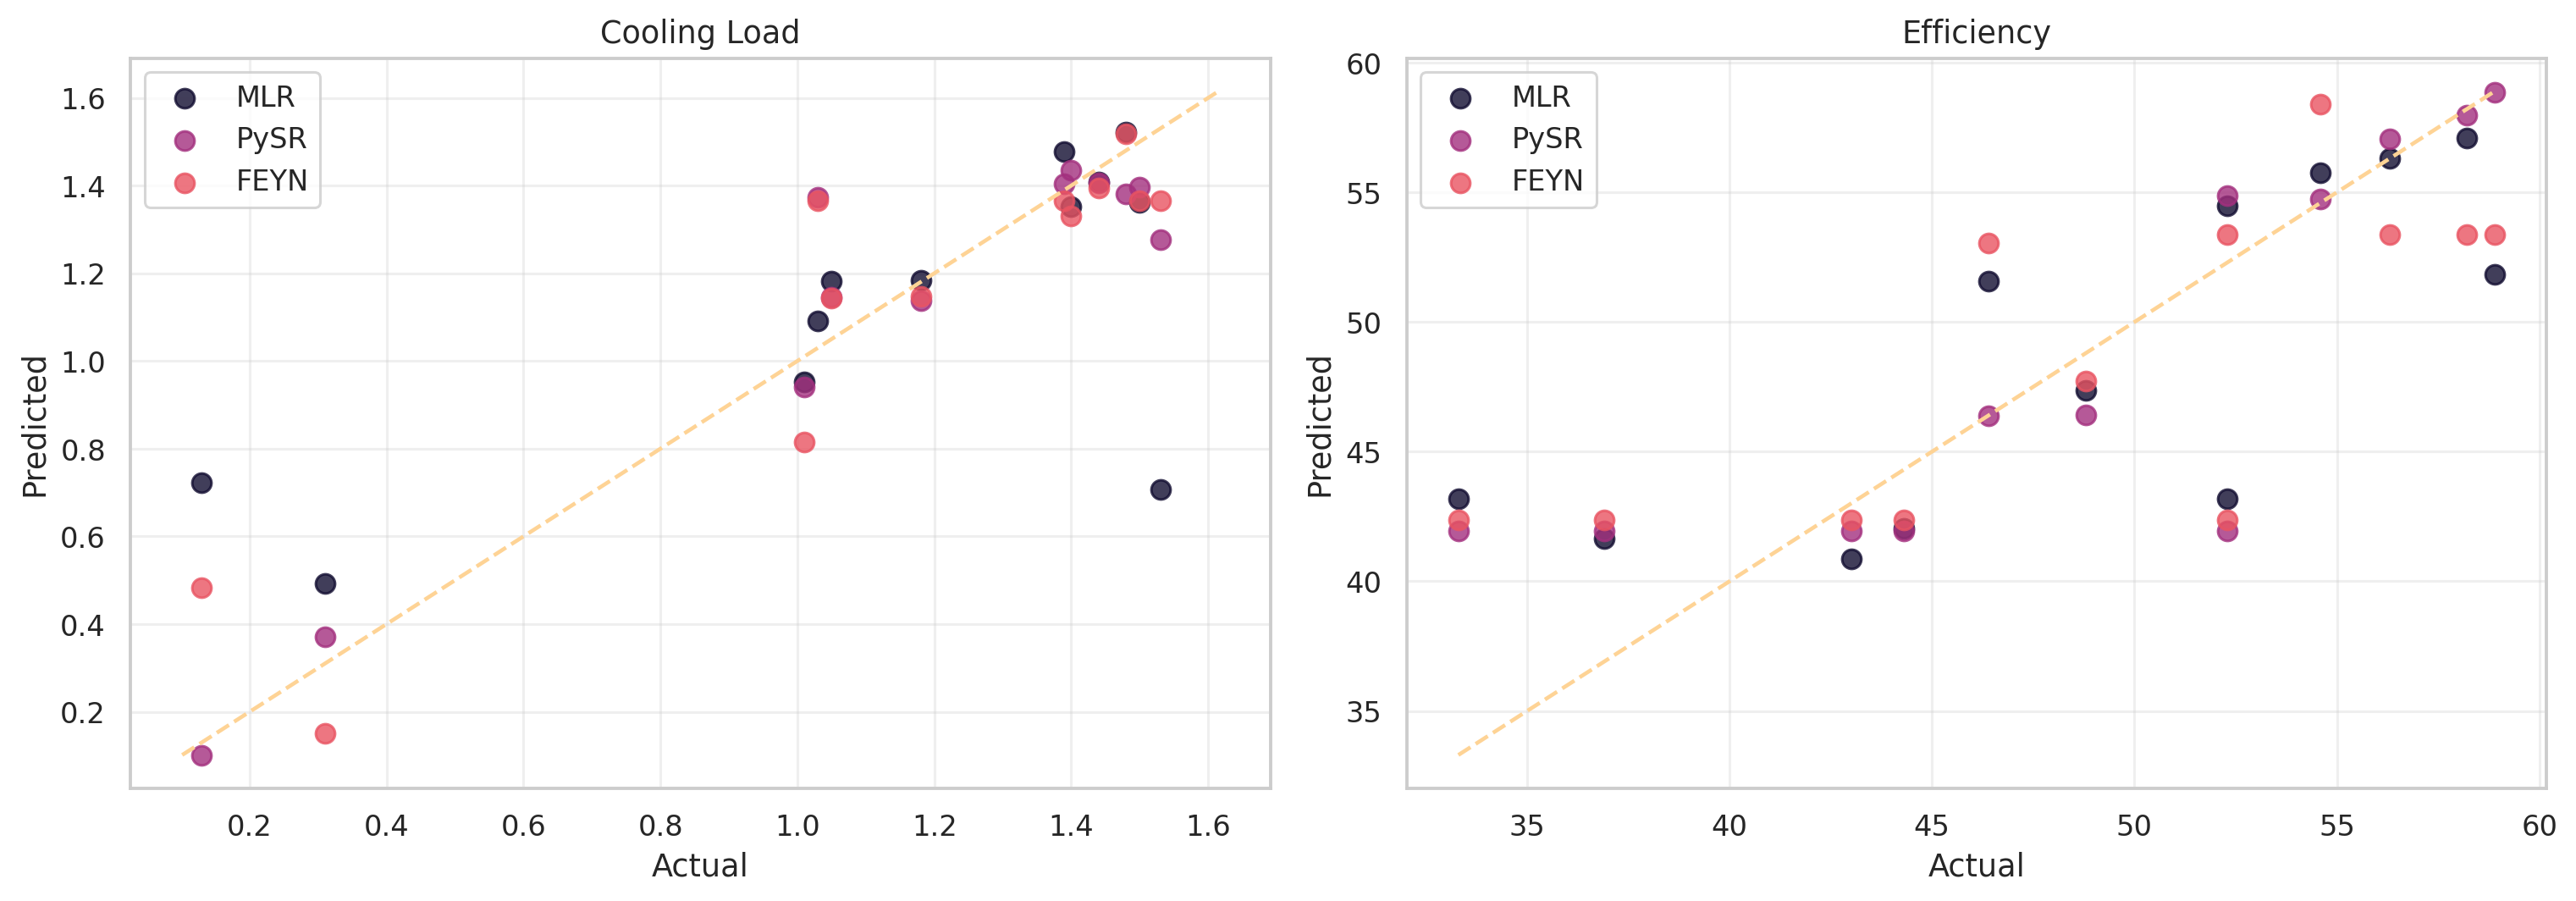

Final developed equations and metrics (updated with FEYN):


,Model,Target,Equation,R2,RMSE
0,MLR,Cooling Load,Cooling_Load = -3.006680 +0.460945*WFR +0.077031*WIT +0.011321*AFR,0.5261,0.3053
1,MLR,Efficiency,Efficiency = 47.989193 -8.384705*WFR +0.527973*WIT -0.077229*AFR,0.5999,4.9884
2,PySR,Cooling Load,(0.18512224 / (-20.90176 * (WFR + -1.4857113))) + sqrt((WFR - 0.6671222) - (WFR / (WIT - AFR))),0.9045,0.1371
3,PySR,Efficiency,(1.9930205 / (WIT + (WFR * -23.637854))) + sqrt((108.151215 + (WFR * -23.081179)) * WIT),0.6959,4.3491
4,FEYN,Cooling Load,8.77403*(5.17237 - 2.0713*WFRLmin)*(7.26472 - 0.241763*AFRLs) + 1.14489,0.8456,0.1743
5,FEYN,Efficiency,69.0948 - 10.6944*WFRLmin,0.5467,5.3097


In [45]:




if feyn_ok:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))


    axes[0].scatter(y_cl, y_cl_pred_feyn, color=pal[6], s=60, alpha=0.85)
    mn = min(np.min(y_cl), np.min(y_cl_pred_feyn)); mx = max(np.max(y_cl), np.max(y_cl_pred_feyn))
    axes[0].plot([mn, mx], [mn, mx], linestyle='--', color=pal[9], lw=1.5)
    axes[0].set_title('Cooling Load')
    axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].grid(True, alpha=0.3)

    axes[1].scatter(y_eff, y_eff_pred_feyn, color=pal[7], s=60, alpha=0.85)
    mn = min(np.min(y_eff), np.min(y_eff_pred_feyn)); mx = max(np.max(y_eff), np.max(y_eff_pred_feyn))
    axes[1].plot([mn, mx], [mn, mx], linestyle='--', color=pal[9], lw=1.5)
    axes[1].set_title('Efficiency')
    axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted'); axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()


if feyn_ok:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))



    axes[0].scatter(y_cl, y_cl_pred_mlr, label='MLR', s=55, alpha=0.8, color=pal[0])

    if 'pysr_ok' in globals() and pysr_ok:
        axes[0].scatter(y_cl, y_cl_pred_pysr, label='PySR', s=55, alpha=0.8, color=pal[4])
    axes[0].scatter(y_cl, y_cl_pred_feyn, label='FEYN', s=55, alpha=0.8, color=pal[6])

    line_min = min(
        y_cl.min(), y_cl_pred_mlr.min(), y_cl_pred_gams.min(), y_cl_pred_feyn.min(),
        y_cl_pred_pysr.min() if ('pysr_ok' in globals() and pysr_ok) else y_cl_pred_feyn.min()
    )
    line_max = max(
        y_cl.max(), y_cl_pred_mlr.max(), y_cl_pred_gams.max(), y_cl_pred_feyn.max(),
        y_cl_pred_pysr.max() if ('pysr_ok' in globals() and pysr_ok) else y_cl_pred_feyn.max()
    )
    axes[0].plot([line_min, line_max], [line_min, line_max], linestyle='--', color=pal[9], lw=1.5)
    axes[0].set_title('Cooling Load')
    axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
    axes[0].grid(True, alpha=0.3); axes[0].legend()


    axes[1].scatter(y_eff, y_eff_pred_mlr, label='MLR', s=55, alpha=0.8, color=pal[0])

    if 'pysr_ok' in globals() and pysr_ok:
        axes[1].scatter(y_eff, y_eff_pred_pysr, label='PySR', s=55, alpha=0.8, color=pal[4])
    axes[1].scatter(y_eff, y_eff_pred_feyn, label='FEYN', s=55, alpha=0.8, color=pal[6])

    line_min = min(
        y_eff.min(), y_eff_pred_mlr.min(), y_eff_pred_gams.min(), y_eff_pred_feyn.min(),
        y_eff_pred_pysr.min() if ('pysr_ok' in globals() and pysr_ok) else y_eff_pred_feyn.min()
    )
    line_max = max(
        y_eff.max(), y_eff_pred_mlr.max(), y_eff_pred_gams.max(), y_eff_pred_feyn.max(),
        y_eff_pred_pysr.max() if ('pysr_ok' in globals() and pysr_ok) else y_eff_pred_feyn.max()
    )
    axes[1].plot([line_min, line_max], [line_min, line_max], linestyle='--', color=pal[9], lw=1.5)
    axes[1].set_title('Efficiency')
    axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
    axes[1].grid(True, alpha=0.3); axes[1].legend()

    plt.tight_layout(); plt.show()


def _rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

rows_updated = []
rows_updated.append({'Model': 'MLR', 'Target': 'Cooling Load', 'Equation': eq_mlr_cl, 'R2': r2_score(y_cl, y_cl_pred_mlr), 'RMSE': _rmse(y_cl, y_cl_pred_mlr)})
rows_updated.append({'Model': 'MLR', 'Target': 'Efficiency', 'Equation': eq_mlr_eff, 'R2': r2_score(y_eff, y_eff_pred_mlr), 'RMSE': _rmse(y_eff, y_eff_pred_mlr)})



if 'pysr_ok' in globals() and pysr_ok:
    rows_updated.append({'Model': 'PySR', 'Target': 'Cooling Load', 'Equation': eq_pysr_cl, 'R2': r2_score(y_cl, y_cl_pred_pysr), 'RMSE': _rmse(y_cl, y_cl_pred_pysr)})
    rows_updated.append({'Model': 'PySR', 'Target': 'Efficiency', 'Equation': eq_pysr_eff, 'R2': r2_score(y_eff, y_eff_pred_pysr), 'RMSE': _rmse(y_eff, y_eff_pred_pysr)})

if feyn_ok:
    rows_updated.append({'Model': 'FEYN', 'Target': 'Cooling Load', 'Equation': eq_feyn_cl, 'R2': r2_score(y_cl, y_cl_pred_feyn), 'RMSE': _rmse(y_cl, y_cl_pred_feyn)})
    rows_updated.append({'Model': 'FEYN', 'Target': 'Efficiency', 'Equation': eq_feyn_eff, 'R2': r2_score(y_eff, y_eff_pred_feyn), 'RMSE': _rmse(y_eff, y_eff_pred_feyn)})

final_table = pd.DataFrame(rows_updated)
print('Final developed equations and metrics (updated with FEYN):')
display(final_table.style.format({'R2': '{:.4f}', 'RMSE': '{:.4f}'}))

In [19]:
df_final.head()

,WFR_L_min,WIT_degC,AFR_L_s,Cooling_Load_kW,Effectiveness_pct
0,1.00,35.0,30.2,0.31,54.6
1,1.50,35.0,30.2,0.13,46.4
2,2.00,35.0,30.2,1.01,48.8
3,2.50,35.0,30.2,1.18,33.3
4,1.47,35.0,30.0,1.53,58.9


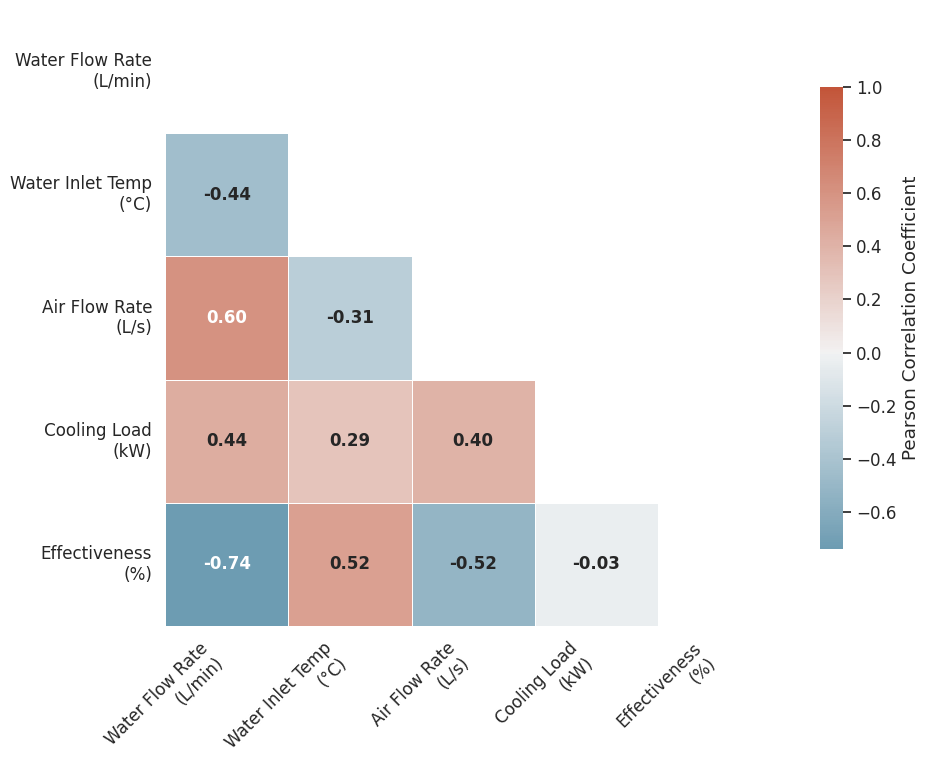

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


custom_names = {
    'WFR_L_min': 'Water Flow Rate\n(L/min)',
    'WIT_degC': 'Water Inlet Temp\n(°C)',
    'AFR_L_s': 'Air Flow Rate\n(L/s)',
    'Cooling_Load_kW': 'Cooling Load\n(kW)',
    'Effectiveness_pct': 'Effectiveness\n(%)'
}


corr_df = df_final.rename(columns=custom_names).corr(numeric_only=True)


mask = np.triu(np.ones_like(corr_df, dtype=bool))


sns.set_theme(style="white", font_scale=1.1)
cmap = sns.diverging_palette(230, 20, as_cmap=True)


plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(
    corr_df,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .75, "label": "Pearson Correlation Coefficient"},
    annot_kws={"size": 12, "weight": "bold"}
)



plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)


plt.savefig('correlation_heatmap_high_res.png', dpi=300, bbox_inches='tight')